In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

base = "/content/drive/MyDrive/Leaf_Disease_Project"

print("Base contents:", os.listdir(base))

print("Preprocessed_Data:", os.listdir(base+"/Preprocessed_Data"))
print("Synthetic_Data:", os.listdir(base+"/Synthetic_Data"))
print("CNN_Data:", os.listdir(base+"/CNN_Data"))

Base contents: ['archive (7).zip', 'PlantVillage', 'plantvillage', 'Preprocessed_Data', 'Synthetic_Data', 'Selected_Data', 'Models', 'CNN_Data']
Preprocessed_Data: ['Pepper__bell___healthy', 'Pepper__bell___Bacterial_spot', 'Potato___healthy', 'Potato___Late_blight', 'Tomato_healthy', 'Tomato_Early_blight']
Synthetic_Data: ['Potato___healthy', 'Potato___Late_blight']
CNN_Data: ['Real', 'Synthetic', 'Mixed', 'Mixed_Train']


In [ ]:
import os

path = "/content/drive/MyDrive/Leaf_Disease_Project"
print(os.listdir(path))

['archive (7).zip', 'PlantVillage', 'plantvillage', 'Preprocessed_Data', 'Synthetic_Data', 'Selected_Data', 'Models', 'CNN_Data']


In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/Leaf_Disease_Project/archive (7).zip"
extract_path = "/content/drive/MyDrive/Leaf_Disease_Project/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Leaf_Disease_Project/archive (7).zip'

In [ ]:
base_path = "/content/drive/MyDrive/Leaf_Disease_Project/PlantVillage"
print(len(os.listdir(base_path)))
print(os.listdir(base_path)[:10])

15
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot']


In [ ]:
import os

selected_path = "/content/drive/MyDrive/Leaf_Disease_Project/Selected_Data"
os.makedirs(selected_path, exist_ok=True)

print("Selected_Data folder created")

Selected_Data folder created


In [ ]:
import os

base = "/content/drive/MyDrive/Leaf_Disease_Project"
print(os.listdir(base))

['archive (7).zip', 'PlantVillage', 'plantvillage', 'Preprocessed_Data', 'Synthetic_Data', 'Selected_Data', 'Models', 'CNN_Data']


In [ ]:
import shutil
import os

source_path = "/content/drive/MyDrive/Leaf_Disease_Project/PlantVillage"
selected_path = "/content/drive/MyDrive/Leaf_Disease_Project/Selected_Data"

folders = [
    "Pepper__bell___healthy",
    "Pepper__bell___Bacterial_spot",
    "Potato___healthy",
    "Potato___Late_blight",
    "Tomato_healthy",
    "Tomato_Early_blight"
]

for folder in folders:
    src = os.path.join(source_path, folder)
    dst = os.path.join(selected_path, folder)

    if os.path.exists(src):
        shutil.copytree(src, dst, dirs_exist_ok=True)
        print("Copied:", folder)
    else:
        print("Not found:", folder)

Copied: Pepper__bell___healthy
Copied: Pepper__bell___Bacterial_spot
Copied: Potato___healthy


KeyboardInterrupt: 

In [ ]:
import os

selected_path = "/content/drive/MyDrive/Leaf_Disease_Project/Selected_Data"

for folder in os.listdir(selected_path):
    folder_path = os.path.join(selected_path, folder)
    print(folder, ":", len(os.listdir(folder_path)))

Pepper__bell___Bacterial_spot : 997
Potato___Late_blight : 1000
Potato___healthy : 152
Tomato_Early_blight : 1000
Tomato_healthy : 1591
Pepper__bell___healthy : 1478


In [ ]:
import os

preprocessed_path = "/content/drive/MyDrive/Leaf_Disease_Project/Preprocessed_Data"
os.makedirs(preprocessed_path, exist_ok=True)

print("Preprocessed_Data folder created")

In [ ]:
import os
import cv2
from tqdm import tqdm

selected_path = "/content/drive/MyDrive/Leaf_Disease_Project/Selected_Data"
preprocessed_path = "/content/drive/MyDrive/Leaf_Disease_Project/Preprocessed_Data"

IMG_SIZE = 64

for class_name in os.listdir(selected_path):

    src_folder = os.path.join(selected_path, class_name)
    dst_folder = os.path.join(preprocessed_path, class_name)

    os.makedirs(dst_folder, exist_ok=True)

    print(f"Processing {class_name}...")

    for img_name in tqdm(os.listdir(src_folder)):

        img_path = os.path.join(src_folder, img_name)

        try:
            img = cv2.imread(img_path)

            if img is None:
                continue

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            save_path = os.path.join(dst_folder, img_name)

            cv2.imwrite(save_path, img)

        except:
            continue

print("Preprocessing Complete")

Processing Tomato_Early_blight...


100%|██████████| 1000/1000 [00:35<00:00, 27.82it/s]


Processing Tomato_healthy...


100%|██████████| 1591/1591 [01:02<00:00, 25.39it/s]


Processing Potato___Late_blight...


...

Processing Pepper__bell___healthy...


100%|██████████| 1478/1478 [00:59<00:00, 24.71it/s]


Processing Pepper__bell___Bacterial_spot...


100%|██████████| 997/997 [00:33<00:00, 29.63it/s]

Preprocessing Complete


In [ ]:
for folder in os.listdir(preprocessed_path):
    print(folder, len(os.listdir(os.path.join(preprocessed_path, folder))))

In [2]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
import os

synthetic_path = "/content/drive/MyDrive/Leaf_Disease_Project/Synthetic_Data"
os.makedirs(synthetic_path, exist_ok=True)

print("Synthetic_Data folder created")

In [ ]:
class_name = "Potato___healthy"

class_synthetic_path = os.path.join(
    "/content/drive/MyDrive/Leaf_Disease_Project/Synthetic_Data",
    class_name
)

os.makedirs(class_synthetic_path, exist_ok=True)

print("Folder created for", class_name)

In [ ]:
preprocessed_path = "/content/drive/MyDrive/Leaf_Disease_Project/Preprocessed_Data"

import os
print(os.listdir(preprocessed_path))

['Pepper__bell___healthy', 'Pepper__bell___Bacterial_spot', 'Potato___healthy', 'Potato___Late_blight', 'Tomato_healthy', 'Tomato_Early_blight']


In [ ]:
import os

base_path = "/content/drive/MyDrive/Leaf_Disease_Project"

print(os.listdir(base_path))

['archive (7).zip', 'PlantVillage', 'plantvillage', 'Preprocessed_Data', 'Synthetic_Data', 'Selected_Data', 'Models', 'CNN_Data']


In [ ]:
import os

base = "/content/drive/MyDrive/Leaf_Disease_Project"

print("Contents of PlantVillage:")
print(os.listdir(os.path.join(base, "PlantVillage")))

print("\nContents of plantvillage:")
print(os.listdir(os.path.join(base, "plantvillage")))

Contents of PlantVillage:
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']

Contents of plantvillage:
['PlantVillage']


In [ ]:
import os

base_path = "/content/drive/MyDrive/Leaf_Disease_Project"

selected_path = os.path.join(base_path, "Selected_Data")

os.makedirs(selected_path, exist_ok=True)

print("Selected_Data created")

Selected_Data created


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/Leaf_Disease_Project/PlantVillage"

print(os.listdir(dataset_path))

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [ ]:
import shutil
import os

source_path = "/content/drive/MyDrive/Leaf_Disease_Project/PlantVillage"
selected_path = "/content/drive/MyDrive/Leaf_Disease_Project/Selected_Data"

folders = [
    "Pepper__bell___healthy",
    "Pepper__bell___Bacterial_spot",
    "Potato___healthy",
    "Potato___Late_blight",
    "Tomato_healthy",
    "Tomato_Early_blight"
]

for folder in folders:

    src = os.path.join(source_path, folder)
    dst = os.path.join(selected_path, folder)

    shutil.copytree(src, dst, dirs_exist_ok=True)

    print("Copied:", folder)

KeyboardInterrupt: 

In [ ]:
print(os.listdir(selected_path))

['Pepper__bell___Bacterial_spot', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Early_blight', 'Tomato_healthy', 'Pepper__bell___healthy']


In [ ]:
import os
import cv2
from tqdm import tqdm

selected_path = "/content/drive/MyDrive/Leaf_Disease_Project/Selected_Data"
preprocessed_path = "/content/drive/MyDrive/Leaf_Disease_Project/Preprocessed_Data"

os.makedirs(preprocessed_path, exist_ok=True)

IMG_SIZE = 64

for class_name in os.listdir(selected_path):

    src_folder = os.path.join(selected_path, class_name)
    dst_folder = os.path.join(preprocessed_path, class_name)

    os.makedirs(dst_folder, exist_ok=True)

    print("Processing:", class_name)

    for img_name in tqdm(os.listdir(src_folder)):

        img_path = os.path.join(src_folder, img_name)

        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        save_path = os.path.join(dst_folder, img_name)

        cv2.imwrite(save_path, img)

print("Preprocessing Complete")

Processing: Pepper__bell___Bacterial_spot


  1%|          | 7/997 [00:03<07:43,  2.14it/s]


KeyboardInterrupt: 

In [ ]:
for folder in os.listdir(preprocessed_path):
    print(folder, len(os.listdir(os.path.join(preprocessed_path, folder))))

Pepper__bell___healthy 1478
Pepper__bell___Bacterial_spot 997
Potato___healthy 152
Potato___Late_blight 1000
Tomato_healthy 1591
Tomato_Early_blight 1000


In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import torchvision.utils as vutils

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Imports and device ready:", device)

Imports and device ready: cuda


In [ ]:
class DCGenerator(nn.Module):

    def __init__(self):
        super(DCGenerator, self).__init__()

        self.model = nn.Sequential(

            nn.ConvTranspose2d(100, 512, 4, 1, 0),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, z):

        z = z.view(-1, 100, 1, 1)

        img = self.model(z)

        return img


generator = DCGenerator().to(device)

print("DCGAN Generator created")

DCGAN Generator created


In [ ]:
class DCDiscriminator(nn.Module):

    def __init__(self):
        super(DCDiscriminator, self).__init__()

        self.model = nn.Sequential(

            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, 4, 1, 0),
            nn.Sigmoid()
        )

    def forward(self, img):

        validity = self.model(img)

        return validity.view(-1, 1)


discriminator = DCDiscriminator().to(device)

print("DCGAN Discriminator created")

DCGAN Discriminator created


In [ ]:
optimizer_G = torch.optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))

optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

print("Optimizers reset for DCGAN")

Optimizers reset for DCGAN


In [ ]:
from torch.utils.data import Dataset, DataLoader
import cv2
import numpy as np

class LeafDataset(Dataset):

    def __init__(self, folder_path):

        self.folder_path = folder_path

        self.images = os.listdir(folder_path)

    def __len__(self):

        return len(self.images)

    def __getitem__(self, idx):

        img_path = os.path.join(self.folder_path, self.images[idx])

        img = cv2.imread(img_path)

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = img / 127.5 - 1.0

        img = np.transpose(img, (2, 0, 1))

        img = torch.tensor(img, dtype=torch.float32)

        return img


class_name = "Potato___healthy"

dataset = LeafDataset(os.path.join(preprocessed_path, class_name))

dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

print("Dataset loaded:", len(dataset))

Dataset loaded: 152


In [ ]:
epochs = 300

for epoch in range(epochs):

    for real_imgs in dataloader:

        real_imgs = real_imgs.to(device)

        batch_size = real_imgs.size(0)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # Train Discriminator
        optimizer_D.zero_grad()

        outputs = discriminator(real_imgs)
        d_loss_real = criterion(outputs, real_labels)

        z = torch.randn(batch_size, 100).to(device)
        fake_imgs = generator(z)

        outputs = discriminator(fake_imgs.detach())
        d_loss_fake = criterion(outputs, fake_labels)

        d_loss = d_loss_real + d_loss_fake

        d_loss.backward()
        optimizer_D.step()

        # Train Generator
        optimizer_G.zero_grad()

        z = torch.randn(batch_size, 100).to(device)
        fake_imgs = generator(z)

        outputs = discriminator(fake_imgs)

        g_loss = criterion(outputs, real_labels)

        g_loss.backward()
        optimizer_G.step()

    if epoch % 50 == 0:
        print(f"Epoch [{epoch}/{epochs}]  D_loss: {d_loss.item():.4f}  G_loss: {g_loss.item():.4f}")

Epoch [0/300]  D_loss: 0.4055  G_loss: 5.2286
Epoch [50/300]  D_loss: 0.4318  G_loss: 5.1982
Epoch [100/300]  D_loss: 0.3355  G_loss: 2.7246
Epoch [150/300]  D_loss: 0.2322  G_loss: 7.4883
Epoch [200/300]  D_loss: 0.1075  G_loss: 4.1423
Epoch [250/300]  D_loss: 0.1038  G_loss: 5.0676


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

generator.eval()

with torch.no_grad():

    z = torch.randn(1, 100).to(device)

    fake_img = generator(z)

    fake_img = (fake_img + 1) / 2

    img = fake_img[0].cpu().numpy()

    img = np.transpose(img, (1, 2, 0))

    plt.imshow(img)
    plt.title("DCGAN Synthetic Potato Healthy Leaf")
    plt.axis("off")

NameError: name 'generator' is not defined

In [ ]:
import torch
import os

model_path = "/content/drive/MyDrive/Leaf_Disease_Project/Models"
os.makedirs(model_path, exist_ok=True)

# Save Generator
torch.save(generator.state_dict(), os.path.join(model_path, "generator_300.pth"))

# Save Discriminator
torch.save(discriminator.state_dict(), os.path.join(model_path, "discriminator_300.pth"))

print("Models saved after 300 epochs")

Models saved after 300 epochs


In [ ]:
epochs = 300   # additional epochs

for epoch in range(epochs):

    for real_imgs in dataloader:

        real_imgs = real_imgs.to(device)

        batch_size = real_imgs.size(0)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # Train Discriminator
        optimizer_D.zero_grad()

        outputs = discriminator(real_imgs)
        d_loss_real = criterion(outputs, real_labels)

        z = torch.randn(batch_size, 100).to(device)
        fake_imgs = generator(z)

        outputs = discriminator(fake_imgs.detach())
        d_loss_fake = criterion(outputs, fake_labels)

        d_loss = d_loss_real + d_loss_fake

        d_loss.backward()
        optimizer_D.step()

        # Train Generator
        optimizer_G.zero_grad()

        z = torch.randn(batch_size, 100).to(device)
        fake_imgs = generator(z)

        outputs = discriminator(fake_imgs)

        g_loss = criterion(outputs, real_labels)

        g_loss.backward()
        optimizer_G.step()

    if epoch % 50 == 0:
        print(f"Extra Epoch [{epoch}/300] D_loss: {d_loss.item():.4f} G_loss: {g_loss.item():.4f}")

Extra Epoch [0/300] D_loss: 0.0315 G_loss: 4.7034
Extra Epoch [50/300] D_loss: 0.0497 G_loss: 5.5232
Extra Epoch [100/300] D_loss: 0.0091 G_loss: 5.9939
Extra Epoch [150/300] D_loss: 0.0124 G_loss: 6.6468
Extra Epoch [200/300] D_loss: 0.0098 G_loss: 6.3970
Extra Epoch [250/300] D_loss: 0.8158 G_loss: 4.4166


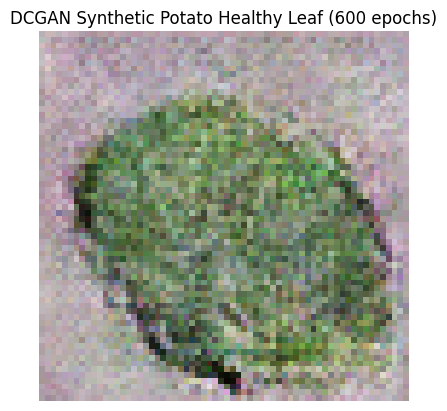

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

generator.eval()

with torch.no_grad():

    z = torch.randn(1, 100).to(device)

    fake_img = generator(z)

    fake_img = (fake_img + 1) / 2

    img = fake_img[0].cpu().numpy()

    img = np.transpose(img, (1, 2, 0))

    plt.imshow(img)
    plt.title("DCGAN Synthetic Potato Healthy Leaf (600 epochs)")
    plt.axis("off")

In [ ]:
import torch
import os

model_path = "/content/drive/MyDrive/Leaf_Disease_Project/Models"
os.makedirs(model_path, exist_ok=True)

torch.save(generator.state_dict(), os.path.join(model_path, "generator_600.pth"))
torch.save(discriminator.state_dict(), os.path.join(model_path, "discriminator_600.pth"))

print("Models saved after 600 epochs")

Models saved after 600 epochs


In [ ]:
epochs = 200

for epoch in range(epochs):

    for real_imgs in dataloader:

        real_imgs = real_imgs.to(device)

        batch_size = real_imgs.size(0)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        optimizer_D.zero_grad()

        outputs = discriminator(real_imgs)
        d_loss_real = criterion(outputs, real_labels)

        z = torch.randn(batch_size, 100).to(device)
        fake_imgs = generator(z)

        outputs = discriminator(fake_imgs.detach())
        d_loss_fake = criterion(outputs, fake_labels)

        d_loss = d_loss_real + d_loss_fake

        d_loss.backward()
        optimizer_D.step()

        optimizer_G.zero_grad()

        z = torch.randn(batch_size, 100).to(device)
        fake_imgs = generator(z)

        outputs = discriminator(fake_imgs)

        g_loss = criterion(outputs, real_labels)

        g_loss.backward()
        optimizer_G.step()

    if epoch % 50 == 0:
        print(f"Extra Epoch [{epoch}/200] D_loss: {d_loss.item():.4f} G_loss: {g_loss.item():.4f}")

Extra Epoch [0/200] D_loss: 0.0680 G_loss: 6.0293
Extra Epoch [50/200] D_loss: 0.0395 G_loss: 4.8022
Extra Epoch [100/200] D_loss: 0.0226 G_loss: 5.6328
Extra Epoch [150/200] D_loss: 0.0150 G_loss: 6.6597


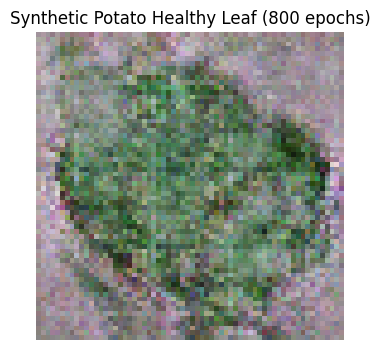

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# set generator to evaluation mode
generator.eval()

with torch.no_grad():

    # create random noise vector
    z = torch.randn(1, 100).to(device)

    # generate synthetic image
    fake_img = generator(z)

    # convert from [-1,1] → [0,1]
    fake_img = (fake_img + 1) / 2

    # convert tensor → numpy
    img = fake_img[0].cpu().numpy()

    # convert from (C,H,W) → (H,W,C)
    img = np.transpose(img, (1, 2, 0))

    # display image
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title("Synthetic Potato Healthy Leaf (800 epochs)")
    plt.axis("off")

In [ ]:
import torch

generator.load_state_dict(
    torch.load("/content/drive/MyDrive/Leaf_Disease_Project/Models/generator_600.pth",
               map_location=device)
)

generator.eval()

print("Generator loaded from 600 epochs successfully")

Generator loaded from 600 epochs successfully


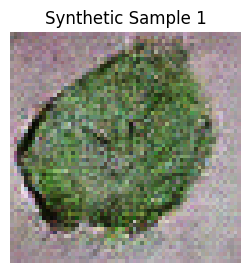

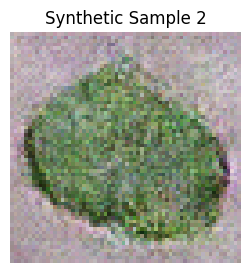

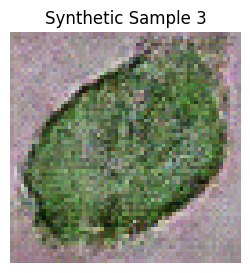

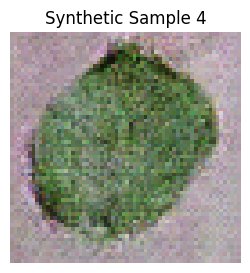

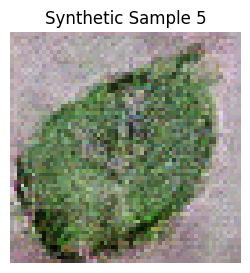

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

for i in range(5):

    z = torch.randn(1, 100).to(device)

    fake_img = generator(z)

    fake_img = (fake_img + 1) / 2

    img = fake_img[0].detach().cpu().numpy()

    img = np.transpose(img, (1, 2, 0))

    plt.figure(figsize=(3,3))
    plt.imshow(img)
    plt.title(f"Synthetic Sample {i+1}")
    plt.axis("off")

In [ ]:
# ============================
# GAN FOR Potato___Late_blight
# ============================

class_name_blight = "Potato___Late_blight"

print("Training GAN for:", class_name_blight)

Training GAN for: Potato___Late_blight


In [ ]:
from torch.utils.data import DataLoader
import os

dataset_blight = LeafDataset(
    os.path.join(preprocessed_path, class_name_blight)
)

dataloader_blight = DataLoader(
    dataset_blight,
    batch_size=32,
    shuffle=True
)

print("Late blight dataset size:", len(dataset_blight))

NameError: name 'LeafDataset' is not defined

In [ ]:
generator_blight = DCGenerator().to(device)
discriminator_blight = DCDiscriminator().to(device)

print("Late blight Generator and Discriminator created")

Late blight Generator and Discriminator created


In [ ]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.BCELoss()

optimizer_G_blight = optim.Adam(
    generator_blight.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

optimizer_D_blight = optim.Adam(
    discriminator_blight.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

print("Late blight optimizers ready")

Late blight optimizers ready


In [ ]:
epochs = 600

for epoch in range(epochs):

    for real_imgs in dataloader_blight:

        real_imgs = real_imgs.to(device)

        batch_size = real_imgs.size(0)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # Train Discriminator
        optimizer_D_blight.zero_grad()

        outputs = discriminator_blight(real_imgs)
        d_loss_real = criterion(outputs, real_labels)

        z = torch.randn(batch_size, 100).to(device)
        fake_imgs = generator_blight(z)

        outputs = discriminator_blight(fake_imgs.detach())
        d_loss_fake = criterion(outputs, fake_labels)

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()

        optimizer_D_blight.step()

        # Train Generator
        optimizer_G_blight.zero_grad()

        z = torch.randn(batch_size, 100).to(device)
        fake_imgs = generator_blight(z)

        outputs = discriminator_blight(fake_imgs)

        g_loss = criterion(outputs, real_labels)

        g_loss.backward()

        optimizer_G_blight.step()

    if epoch % 50 == 0:
        print(f"Epoch [{epoch}/{epochs}] D_loss: {d_loss.item():.4f} G_loss: {g_loss.item():.4f}")

Epoch [0/600] D_loss: 1.0043 G_loss: 12.7933
Epoch [50/600] D_loss: 0.4484 G_loss: 0.5339
Epoch [100/600] D_loss: 0.1942 G_loss: 8.0652
Epoch [150/600] D_loss: 0.0555 G_loss: 5.7959
Epoch [200/600] D_loss: 0.0973 G_loss: 12.0523
Epoch [250/600] D_loss: 0.0174 G_loss: 7.2097
Epoch [300/600] D_loss: 0.1127 G_loss: 5.6673
Epoch [350/600] D_loss: 0.0396 G_loss: 8.3469
Epoch [400/600] D_loss: 0.0140 G_loss: 7.9113
Epoch [450/600] D_loss: 0.0097 G_loss: 8.1465
Epoch [500/600] D_loss: 0.0451 G_loss: 5.2948
Epoch [550/600] D_loss: 0.0052 G_loss: 6.4157


Previewing Late Blight synthetic images...


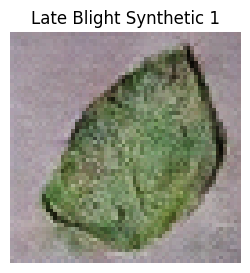

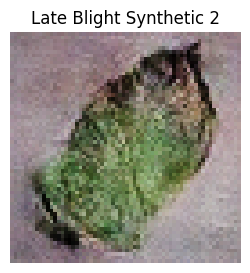

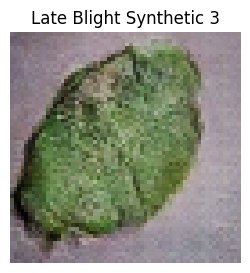

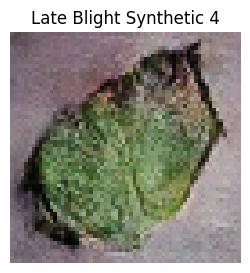

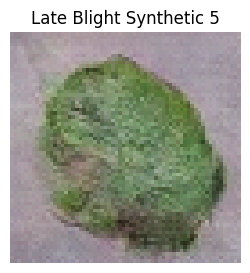

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

generator_blight.eval()

print("Previewing Late Blight synthetic images...")

for i in range(5):

    z = torch.randn(1,100).to(device)

    with torch.no_grad():
        fake_img = generator_blight(z)

    fake_img = (fake_img+1)/2

    img = fake_img[0].detach().cpu().numpy()

    img = np.transpose(img,(1,2,0))

    plt.figure(figsize=(3,3))
    plt.imshow(img)
    plt.title(f"Late Blight Synthetic {i+1}")
    plt.axis("off")

In [ ]:
import os
import torch

# create Models folder if not exists
model_folder = "/content/drive/MyDrive/Leaf_Disease_Project/Models"
os.makedirs(model_folder, exist_ok=True)

# save generator_blight
torch.save(
    generator_blight.state_dict(),
    os.path.join(model_folder, "generator_blight_600.pth")
)

print("generator_blight_600.pth saved successfully")

generator_blight_600.pth saved successfully


In [ ]:
os.listdir("/content/drive/MyDrive/Leaf_Disease_Project/Models")

In [ ]:
import torch
import os
import torchvision.utils as vutils

# define save folder
save_folder = "/content/drive/MyDrive/Leaf_Disease_Project/Synthetic_Data/Potato___Late_blight"

# create folder if not exists
os.makedirs(save_folder, exist_ok=True)

# ensure generator is in evaluation mode
generator_blight.eval()

num_images = 500

print("Generating 500 synthetic Potato___Late_blight images...")

for i in range(num_images):

    # create random noise
    z = torch.randn(1, 100).to(device)

    with torch.no_grad():
        fake_img = generator_blight(z)

    # convert from [-1,1] → [0,1]
    fake_img = (fake_img + 1) / 2

    # save image
    save_path = os.path.join(save_folder, f"synthetic_{i}.png")

    vutils.save_image(fake_img, save_path)

    # progress indicator
    if (i+1) % 100 == 0:
        print(f"{i+1} images saved")

print("Done. 500 synthetic late blight images saved successfully.")

Generating 500 synthetic Potato___Late_blight images...
100 images saved
200 images saved
300 images saved
400 images saved
500 images saved
Done. 500 synthetic late blight images saved successfully.


In [ ]:
import os

base_path = "/content/drive/MyDrive/Leaf_Disease_Project/CNN_Data"

real_path = os.path.join(base_path, "Real")
synthetic_path = os.path.join(base_path, "Synthetic")
mixed_path = os.path.join(base_path, "Mixed")

os.makedirs(real_path, exist_ok=True)
os.makedirs(synthetic_path, exist_ok=True)
os.makedirs(mixed_path, exist_ok=True)

print("CNN_Data folders created")

CNN_Data folders created


In [ ]:
import os

base_path = "/content/drive/MyDrive/Leaf_Disease_Project/CNN_Data"

real_path = os.path.join(base_path, "Real")
synthetic_path = os.path.join(base_path, "Synthetic")
mixed_path = os.path.join(base_path, "Mixed")

os.makedirs(real_path, exist_ok=True)
os.makedirs(synthetic_path, exist_ok=True)
os.makedirs(mixed_path, exist_ok=True)

print("Paths defined successfully")

Paths defined successfully


In [ ]:
import shutil

source_real = "/content/drive/MyDrive/Leaf_Disease_Project/Preprocessed_Data"
dest_real = real_path

classes = ["Potato___healthy", "Potato___Late_blight"]

for cls in classes:

    src = os.path.join(source_real, cls)
    dst = os.path.join(dest_real, cls)

    os.makedirs(dst, exist_ok=True)

    for file in os.listdir(src):
        shutil.copy(os.path.join(src, file),
                    os.path.join(dst, file))

print("Real dataset ready")

Real dataset ready


In [ ]:
source_syn = "/content/drive/MyDrive/Leaf_Disease_Project/Synthetic_Data"
dest_syn = synthetic_path

for cls in classes:

    src = os.path.join(source_syn, cls)
    dst = os.path.join(dest_syn, cls)

    os.makedirs(dst, exist_ok=True)

    for file in os.listdir(src):
        shutil.copy(os.path.join(src, file),
                    os.path.join(dst, file))

print("Synthetic dataset ready")

Synthetic dataset ready


In [ ]:
import shutil
import os

base_path = "/content/drive/MyDrive/Leaf_Disease_Project/CNN_Data"

real_path = os.path.join(base_path, "Real")
synthetic_path = os.path.join(base_path, "Synthetic")
mixed_path = os.path.join(base_path, "Mixed")

classes = ["Potato___healthy", "Potato___Late_blight"]

for cls in classes:

    dst = os.path.join(mixed_path, cls)
    os.makedirs(dst, exist_ok=True)

    # copy real images
    src_real = os.path.join(real_path, cls)

    for file in os.listdir(src_real):
        shutil.copy(
            os.path.join(src_real, file),
            os.path.join(dst, "real_" + file)
        )

    # copy synthetic images
    src_syn = os.path.join(synthetic_path, cls)

    for file in os.listdir(src_syn):
        shutil.copy(
            os.path.join(src_syn, file),
            os.path.join(dst, "syn_" + file)
        )

print("Mixed dataset created successfully")

KeyboardInterrupt: 

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# image transform
transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

# load Real dataset
real_dataset = datasets.ImageFolder(
    "/content/drive/MyDrive/Leaf_Disease_Project/CNN_Data/Real",
    transform=transform
)

# split into train (80%) and test (20%)
train_size = int(0.8 * len(real_dataset))
test_size = len(real_dataset) - train_size

real_train_dataset, real_test_dataset = random_split(
    real_dataset, [train_size, test_size]
)

print("Total real images:", len(real_dataset))
print("Train images:", len(real_train_dataset))
print("Test images:", len(real_test_dataset))

Total real images: 1152
Train images: 921
Test images: 231


In [ ]:
batch_size = 32

real_train_loader = DataLoader(
    real_train_dataset,
    batch_size=batch_size,
    shuffle=True
)

real_test_loader = DataLoader(
    real_test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Real dataloaders ready")

Real dataloaders ready


In [ ]:
import torch.nn as nn

class LeafCNN(nn.Module):

    def __init__(self):
        super(LeafCNN, self).__init__()

        self.conv_layers = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2)
        )

        self.fc_layers = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128*8*8, 128),
            nn.ReLU(),

            nn.Linear(128, 2)   # 2 classes: healthy and blight
        )

    def forward(self, x):

        x = self.conv_layers(x)
        x = self.fc_layers(x)

        return x


# create model
device = torch.device("cpu")

model = LeafCNN().to(device)

print("CNN model created")

CNN model created


In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss and optimizer ready")

Loss and optimizer ready


In [ ]:
epochs = 10

train_losses = []

for epoch in range(epochs):

    model.train()

    running_loss = 0.0

    for images, labels in real_train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # clear gradients
        optimizer.zero_grad()

        # forward pass
        outputs = model(images)

        # compute loss
        loss = criterion(outputs, labels)

        # backward pass
        loss.backward()

        # update weights
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(real_train_loader)

    train_losses.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f}")

Epoch [1/10] Loss: 0.4926
Epoch [2/10] Loss: 0.3794
Epoch [3/10] Loss: 0.2642
Epoch [4/10] Loss: 0.1686
Epoch [5/10] Loss: 0.1220
Epoch [6/10] Loss: 0.1251
Epoch [7/10] Loss: 0.0819
Epoch [8/10] Loss: 0.0642
Epoch [9/10] Loss: 0.0696
Epoch [10/10] Loss: 0.0471


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in real_test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy_real = 100 * correct / total

print(f"Real Dataset Test Accuracy: {accuracy_real:.2f}%")

Real Dataset Test Accuracy: 95.24%


In [ ]:
# load Synthetic dataset
synthetic_dataset = datasets.ImageFolder(
    "/content/drive/MyDrive/Leaf_Disease_Project/CNN_Data/Synthetic",
    transform=transform
)

print("Synthetic dataset size:", len(synthetic_dataset))

# create dataloader
synthetic_train_loader = DataLoader(
    synthetic_dataset,
    batch_size=32,
    shuffle=True
)

print("Synthetic dataloader ready")

Synthetic dataset size: 1000
Synthetic dataloader ready


In [ ]:
synthetic_model = LeafCNN().to(device)

synthetic_optimizer = optim.Adam(
    synthetic_model.parameters(),
    lr=0.001
)

print("Synthetic CNN model ready")

Synthetic CNN model ready


In [ ]:
epochs = 10

for epoch in range(epochs):

    synthetic_model.train()

    running_loss = 0.0

    for images, labels in synthetic_train_loader:

        images = images.to(device)
        labels = labels.to(device)

        synthetic_optimizer.zero_grad()

        outputs = synthetic_model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        synthetic_optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(synthetic_train_loader)

    print(f"Synthetic Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f}")

Synthetic Epoch [1/10] Loss: 0.6384
Synthetic Epoch [2/10] Loss: 0.2203
Synthetic Epoch [3/10] Loss: 0.0378
Synthetic Epoch [4/10] Loss: 0.0156
Synthetic Epoch [5/10] Loss: 0.0067
Synthetic Epoch [6/10] Loss: 0.0011
Synthetic Epoch [7/10] Loss: 0.0006
Synthetic Epoch [8/10] Loss: 0.0004
Synthetic Epoch [9/10] Loss: 0.0003
Synthetic Epoch [10/10] Loss: 0.0003


In [ ]:
synthetic_model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in real_test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = synthetic_model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy_synthetic = 100 * correct / total

print(f"Synthetic Dataset Test Accuracy: {accuracy_synthetic:.2f}%")

Synthetic Dataset Test Accuracy: 59.74%


In [ ]:
import os
import shutil

# Correct mixed train folder
correct_mixed_path = "/content/drive/MyDrive/Leaf_Disease_Project/CNN_Data/Mixed_Train"

classes = ["Potato___healthy", "Potato___Late_blight"]

os.makedirs(correct_mixed_path, exist_ok=True)

# Get indices used in real_train_dataset
train_indices = real_train_dataset.indices

# Copy ONLY real TRAIN images
for idx in train_indices:

    img_path, label = real_dataset.samples[idx]

    class_name = real_dataset.classes[label]

    dst = os.path.join(correct_mixed_path, class_name)

    os.makedirs(dst, exist_ok=True)

    filename = os.path.basename(img_path)

    shutil.copy(
        img_path,
        os.path.join(dst, "real_" + filename)
    )

print("Real TRAIN images copied")


# Copy synthetic images
synthetic_path = "/content/drive/MyDrive/Leaf_Disease_Project/CNN_Data/Synthetic"

for cls in classes:

    src_cls = os.path.join(synthetic_path, cls)

    dst_cls = os.path.join(correct_mixed_path, cls)

    os.makedirs(dst_cls, exist_ok=True)

    for file in os.listdir(src_cls):

        shutil.copy(
            os.path.join(src_cls, file),
            os.path.join(dst_cls, "syn_" + file)
        )

print("Synthetic images copied")
print("Correct Mixed_Train dataset ready")

Real TRAIN images copied
Synthetic images copied
Correct Mixed_Train dataset ready


In [ ]:
mixed_dataset = datasets.ImageFolder(
    "/content/drive/MyDrive/Leaf_Disease_Project/CNN_Data/Mixed_Train",
    transform=transform
)
print("Mixed dataset size:", len(mixed_dataset))

mixed_train_loader = DataLoader(
    mixed_dataset,
    batch_size=32,
    shuffle=True
)

print("Mixed dataloader ready")

Mixed dataset size: 2116
Mixed dataloader ready


In [ ]:
mixed_model = LeafCNN().to(device)

mixed_optimizer = optim.Adam(
    mixed_model.parameters(),
    lr=0.001
)

print("Mixed CNN model ready")

Mixed CNN model ready


In [ ]:
epochs = 10

for epoch in range(epochs):

    mixed_model.train()

    running_loss = 0.0

    for images, labels in mixed_train_loader:

        images = images.to(device)
        labels = labels.to(device)

        mixed_optimizer.zero_grad()

        outputs = mixed_model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        mixed_optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(mixed_train_loader)

    print(f"Mixed Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f}")

Mixed Epoch [1/10] Loss: 0.4735
Mixed Epoch [2/10] Loss: 0.1797
Mixed Epoch [3/10] Loss: 0.0700
Mixed Epoch [4/10] Loss: 0.1169
Mixed Epoch [5/10] Loss: 0.1199
Mixed Epoch [6/10] Loss: 0.0555
Mixed Epoch [7/10] Loss: 0.0593
Mixed Epoch [8/10] Loss: 0.0260
Mixed Epoch [9/10] Loss: 0.0318
Mixed Epoch [10/10] Loss: 0.0189


In [ ]:
mixed_model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in real_test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = mixed_model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy_mixed = 100 * correct / total

print(f"Mixed Dataset Test Accuracy: {accuracy_mixed:.2f}%")

Mixed Dataset Test Accuracy: 97.84%


In [ ]:
from torchvision import transforms

# define ResNet transform
resnet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("ResNet transform defined")

ResNet transform defined


In [ ]:
# Experiment 1: Load dataset from Selected_Data (original resolution)
# Using stratified split so test set is FIXED and same across all experiments

import os
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import Subset
from sklearn.model_selection import StratifiedShuffleSplit

data_path = "/content/drive/MyDrive/Leaf_Disease_Project/Selected_Data"

# Load without transform first — just to get labels for stratified split
full_dataset = datasets.ImageFolder(root=data_path)

class_names = full_dataset.classes
labels = np.array([label for _, label in full_dataset.samples])

print("Classes:", class_names)
print("Total images:", len(full_dataset))
print("\nPer class counts:")
for cls, idx in full_dataset.class_to_idx.items():
    print(f"  {cls}: {np.sum(labels == idx)}")

Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Early_blight', 'Tomato_healthy']
Total images: 6218

Per class counts:
  Pepper__bell___Bacterial_spot: 997
  Pepper__bell___healthy: 1478
  Potato___Late_blight: 1000
  Potato___healthy: 152
  Tomato_Early_blight: 1000
  Tomato_healthy: 1591


In [ ]:
# Stratified split 70:15:15 — fixed indices saved so ALL experiments use same test set
# Stratified means each class gets proportional samples in every split

from sklearn.model_selection import StratifiedShuffleSplit

# First split: 70% train, 30% temp
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, temp_idx = next(sss1.split(np.zeros(len(labels)), labels))

# Second split: split the 30% temp into 15% val, 15% test
temp_labels = labels[temp_idx]
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
rel_val_idx, rel_test_idx = next(sss2.split(np.zeros(len(temp_idx)), temp_labels))

val_idx  = temp_idx[rel_val_idx]
test_idx = temp_idx[rel_test_idx]

print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")
print(f"Total: {len(train_idx)+len(val_idx)+len(test_idx)}")

print("\nPer class in Test set:")
for cls, idx in full_dataset.class_to_idx.items():
    cnt = np.sum(labels[test_idx] == idx)
    print(f"  {cls}: {cnt}")

Train: 4352 | Val: 933 | Test: 933
Total: 6218

Per class in Test set:
  Pepper__bell___Bacterial_spot: 150
  Pepper__bell___healthy: 222
  Potato___Late_blight: 150
  Potato___healthy: 23
  Tomato_Early_blight: 150
  Tomato_healthy: 238


In [ ]:
# Create dataloaders using stratified indices with correct transforms
# num_workers=0 is faster on Colab with Google Drive

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from PIL import Image

class SafeImageFolder(datasets.ImageFolder):
    def __getitem__(self, index):
        try:
            return super().__getitem__(index)
        except Exception:
            return super().__getitem__((index + 1) % len(self))

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = Subset(
    SafeImageFolder(root=data_path, transform=train_transform),
    train_idx
)
val_dataset = Subset(
    SafeImageFolder(root=data_path, transform=val_test_transform),
    val_idx
)
test_dataset = Subset(
    SafeImageFolder(root=data_path, transform=val_test_transform),
    test_idx
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,
                          num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False,
                          num_workers=0)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print("Dataloaders ready")

Train: 4352 | Val: 933 | Test: 933
Dataloaders ready


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [ ]:
import torch
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

model = resnet50(weights=ResNet50_Weights.DEFAULT)

# freeze 70%
total_layers = len(list(model.parameters()))
freeze_layers = int(0.7 * total_layers)

for i, param in enumerate(model.parameters()):
    if i < freeze_layers:
        param.requires_grad = False
    else:
        param.requires_grad = True

# replace final layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 6)

model = model.to(device)

print("ResNet50 ready")

ResNet50 ready


In [ ]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001
)

print("Optimizer ready")

Optimizer ready


In [ ]:
epochs = 10

train_losses = []
val_losses = []

for epoch in range(epochs):

    # TRAINING
    model.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_train_loss / len(train_loader)
    train_accuracy = 100 * correct_train / total_train

    # VALIDATION
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_loss = running_val_loss / len(val_loader)
    val_accuracy = 100 * correct_val / total_val

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.2f}%")
    print("------")

Epoch [1/10]
Train Loss: 0.3985 | Train Acc: 89.89%
Val Loss: 0.0232 | Val Acc: 99.46%
------
Epoch [2/10]
Train Loss: 0.0304 | Train Acc: 99.36%
Val Loss: 0.0176 | Val Acc: 99.46%
------
Epoch [3/10]
Train Loss: 0.0169 | Train Acc: 99.54%
Val Loss: 0.0147 | Val Acc: 99.68%
------
Epoch [4/10]
Train Loss: 0.0101 | Train Acc: 99.77%
Val Loss: 0.0101 | Val Acc: 99.79%
------
Epoch [5/10]
Train Loss: 0.0102 | Train Acc: 99.79%
Val Loss: 0.0116 | Val Acc: 99.46%
------
Epoch [6/10]
Train Loss: 0.0041 | Train Acc: 99.91%
Val Loss: 0.0206 | Val Acc: 99.25%
------
Epoch [7/10]
Train Loss: 0.0105 | Train Acc: 99.72%
Val Loss: 0.0118 | Val Acc: 99.68%
------
Epoch [8/10]
Train Loss: 0.0060 | Train Acc: 99.82%
Val Loss: 0.0077 | Val Acc: 99.79%
------
Epoch [9/10]
Train Loss: 0.0030 | Train Acc: 99.93%
Val Loss: 0.0077 | Val Acc: 99.79%
------
Epoch [10/10]
Train Loss: 0.0076 | Train Acc: 99.77%
Val Loss: 0.0134 | Val Acc: 99.57%
------


In [ ]:
import torch

save_path = "/content/drive/MyDrive/Leaf_Disease_Project/Models/resnet50_6class_real.pth"

torch.save(model.state_dict(), save_path)

print("Model saved successfully")

Model saved successfully


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 99.14%


In [ ]:
# Experiment 1 - Full metrics on test set
import torch
import numpy as np
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    balanced_accuracy_score
)
from sklearn.preprocessing import label_binarize

model.eval()

all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)
all_probs  = np.array(all_probs)

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

from sklearn.metrics import f1_score
print("\nMacro F1:    ", f1_score(all_labels, all_preds, average="macro"))
print("Weighted F1: ", f1_score(all_labels, all_preds, average="weighted"))
print("Balanced Accuracy:", balanced_accuracy_score(all_labels, all_preds))

labels_bin = label_binarize(all_labels, classes=range(len(class_names)))
print("AUC (OvR):   ", roc_auc_score(labels_bin, all_probs, multi_class="ovr"))

Classification Report:
                               precision    recall  f1-score   support

Pepper__bell___Bacterial_spot       1.00      0.97      0.99       150
       Pepper__bell___healthy       0.98      1.00      0.99       222
         Potato___Late_blight       1.00      0.99      0.99       150
             Potato___healthy       0.92      0.96      0.94        23
          Tomato_Early_blight       1.00      0.99      1.00       150
               Tomato_healthy       1.00      1.00      1.00       238

                     accuracy                           0.99       933
                    macro avg       0.98      0.98      0.98       933
                 weighted avg       0.99      0.99      0.99       933

Confusion Matrix:
[[146   4   0   0   0   0]
 [  0 222   0   0   0   0]
 [  0   0 148   2   0   0]
 [  0   1   0  22   0   0]
 [  0   0   0   0 149   1]
 [  0   0   0   0   0 238]]

Macro F1:     0.9832280857885659
Weighted F1:  0.9914527246281599
Balanced Accurac

In [ ]:
# 5-Fold Cross Validation for Experiment 1
# Trains ResNet50 on each fold and reports mean and SD of all metrics

import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score,
    balanced_accuracy_score, roc_auc_score
)
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
import torch
import torch.nn as nn

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Results storage
fold_accuracies  = []
fold_macro_f1    = []
fold_weighted_f1 = []
fold_bal_acc     = []
fold_auc         = []

# Full dataset for CV (no transform yet)
full_ds_notransform = datasets.ImageFolder(root=data_path)
all_labels_cv = np.array([l for _, l in full_ds_notransform.samples])

fold_num = 1

for train_idx_cv, test_idx_cv in skf.split(np.zeros(len(all_labels_cv)), all_labels_cv):

    print(f"\n--- Fold {fold_num}/5 ---")

    # Datasets
    fold_train = Subset(
        SafeImageFolder(root=data_path, transform=train_transform),
        train_idx_cv
    )
    fold_test = Subset(
        SafeImageFolder(root=data_path, transform=val_test_transform),
        test_idx_cv
    )

    fold_train_loader = DataLoader(fold_train, batch_size=32,
                                   shuffle=True,  num_workers=0)
    fold_test_loader  = DataLoader(fold_test,  batch_size=32,
                                   shuffle=False, num_workers=0)

    # Fresh ResNet50 for each fold
    fold_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    layers = list(fold_model.children())
    freeze_until = int(0.7 * len(layers))
    for layer in layers[:freeze_until]:
        for param in layer.parameters():
            param.requires_grad = False
    fold_model.fc = nn.Linear(fold_model.fc.in_features, 6)
    fold_model = fold_model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, fold_model.parameters()),
        lr=0.0001
    )

    # Train for 10 epochs
    for epoch in range(10):
        fold_model.train()
        for images, labels in fold_train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = fold_model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        print(f"  Epoch {epoch+1}/10 done")

    # Evaluate
    fold_model.eval()
    f_preds, f_labels, f_probs = [], [], []
    with torch.no_grad():
        for images, labels in fold_test_loader:
            images = images.to(device)
            outputs = fold_model(images)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            f_preds.extend(preds.cpu().numpy())
            f_labels.extend(labels.numpy())
            f_probs.extend(probs.cpu().numpy())

    f_preds  = np.array(f_preds)
    f_labels = np.array(f_labels)
    f_probs  = np.array(f_probs)

    acc     = accuracy_score(f_labels, f_preds)
    mf1     = f1_score(f_labels, f_preds, average="macro")
    wf1     = f1_score(f_labels, f_preds, average="weighted")
    bal     = balanced_accuracy_score(f_labels, f_preds)
    auc     = roc_auc_score(f_labels, f_probs, multi_class="ovr")

    fold_accuracies.append(acc)
    fold_macro_f1.append(mf1)
    fold_weighted_f1.append(wf1)
    fold_bal_acc.append(bal)
    fold_auc.append(auc)

    print(f"  Fold {fold_num} → Acc: {acc:.4f} | Macro F1: {mf1:.4f} | AUC: {auc:.4f}")
    fold_num += 1

# Final summary
print("\n" + "="*55)
print("  5-FOLD CROSS VALIDATION RESULTS — EXPERIMENT 1")
print("="*55)
print(f"Accuracy:          {np.mean(fold_accuracies):.4f} ± {np.std(fold_accuracies):.4f}")
print(f"Macro F1:          {np.mean(fold_macro_f1):.4f} ± {np.std(fold_macro_f1):.4f}")
print(f"Weighted F1:       {np.mean(fold_weighted_f1):.4f} ± {np.std(fold_weighted_f1):.4f}")
print(f"Balanced Accuracy: {np.mean(fold_bal_acc):.4f} ± {np.std(fold_bal_acc):.4f}")
print(f"AUC (OvR):         {np.mean(fold_auc):.4f} ± {np.std(fold_auc):.4f}")


--- Fold 1/5 ---
  Epoch 1/10 done
  Epoch 2/10 done
  Epoch 3/10 done
  Epoch 4/10 done
  Epoch 5/10 done
  Epoch 6/10 done
  Epoch 7/10 done
  Epoch 8/10 done
  Epoch 9/10 done
  Epoch 10/10 done
  Fold 1 → Acc: 0.9984 | Macro F1: 0.9986 | AUC: 1.0000

--- Fold 2/5 ---
  Epoch 1/10 done
  Epoch 2/10 done
  Epoch 3/10 done
  Epoch 4/10 done
  Epoch 5/10 done
  Epoch 6/10 done
  Epoch 7/10 done
  Epoch 8/10 done
  Epoch 9/10 done
  Epoch 10/10 done
  Fold 2 → Acc: 0.9944 | Macro F1: 0.9828 | AUC: 0.9998

--- Fold 3/5 ---
  Epoch 1/10 done
  Epoch 2/10 done
  Epoch 3/10 done
  Epoch 4/10 done
  Epoch 5/10 done
  Epoch 6/10 done
  Epoch 7/10 done
  Epoch 8/10 done
  Epoch 9/10 done
  Epoch 10/10 done
  Fold 3 → Acc: 0.9968 | Macro F1: 0.9948 | AUC: 1.0000

--- Fold 4/5 ---
  Epoch 1/10 done
  Epoch 2/10 done
  Epoch 3/10 done
  Epoch 4/10 done
  Epoch 5/10 done
  Epoch 6/10 done
  Epoch 7/10 done
  Epoch 8/10 done
  Epoch 9/10 done
  Epoch 10/10 done
  Fold 4 → Acc: 0.9968 | Macro F1: 0

In [ ]:
import torch
import torch.nn as nn
import numpy as np

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score
)

In [ ]:
train_transform_aug = transforms.Compose([

    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


test_val_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
# Experiment 2 - Augmentation using Selected_Data
# Reusing SAME stratified indices as Exp1 so test set is identical

dataset_path = "/content/drive/MyDrive/Leaf_Disease_Project/Selected_Data"

train_transform_aug = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Reuse train_idx, val_idx, test_idx from Exp1 stratified split
train_dataset = Subset(
    SafeImageFolder(root=dataset_path, transform=train_transform_aug),
    train_idx
)
val_dataset = Subset(
    SafeImageFolder(root=dataset_path, transform=val_test_transform),
    val_idx
)
test_dataset = Subset(
    SafeImageFolder(root=dataset_path, transform=val_test_transform),
    test_idx
)

train_loader = DataLoader(train_dataset, batch_size=32,
                          shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=32,
                          shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=32,
                          shuffle=False, num_workers=0)

full_dataset = SafeImageFolder(root=dataset_path)
class_names  = full_dataset.classes
total_size   = len(full_dataset)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print("Classes:", class_names)

Train: 4352 | Val: 933 | Test: 933
Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Early_blight', 'Tomato_healthy']


In [ ]:
print("Total images:", total_size)
print("Classes:", class_names)

Total images: 6218
Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Early_blight', 'Tomato_healthy']


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(pretrained=True)

layers = list(model.children())

freeze_until = int(0.7 * len(layers))

for layer in layers[:freeze_until]:
    for param in layer.parameters():
        param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, 6)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 177MB/s]


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001
)

In [ ]:
num_epochs = 10

for epoch in range(num_epochs):

    # -------- TRAIN --------
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()


    avg_train_loss = train_loss / len(train_loader)
    train_acc = 100 * train_correct / train_total


    # -------- VALIDATION --------
    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()


    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total


    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print("-"*50)

Epoch [1/10]
Train Loss: 0.2040 | Train Acc: 94.19%
Val Loss:   0.0225 | Val Acc:   99.36%
--------------------------------------------------
Epoch [2/10]
Train Loss: 0.0545 | Train Acc: 98.37%
Val Loss:   0.0273 | Val Acc:   99.25%
--------------------------------------------------
Epoch [3/10]
Train Loss: 0.0493 | Train Acc: 98.30%
Val Loss:   0.0387 | Val Acc:   98.93%
--------------------------------------------------
Epoch [4/10]
Train Loss: 0.0307 | Train Acc: 99.08%
Val Loss:   0.0175 | Val Acc:   99.79%
--------------------------------------------------
Epoch [5/10]
Train Loss: 0.0232 | Train Acc: 99.33%
Val Loss:   0.0269 | Val Acc:   99.57%
--------------------------------------------------
Epoch [6/10]
Train Loss: 0.0128 | Train Acc: 99.66%
Val Loss:   0.0260 | Val Acc:   99.46%
--------------------------------------------------
Epoch [7/10]
Train Loss: 0.0111 | Train Acc: 99.66%
Val Loss:   0.0192 | Val Acc:   99.79%
--------------------------------------------------
Epoch 

In [ ]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/Leaf_Disease_Project/Models/resnet50_experiment2_augmented_FIXED.pth"
)

print("Experiment 2 model saved")

Experiment 2 model saved


In [ ]:
model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())


accuracy = accuracy_score(all_labels, all_preds)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

print("\nConfusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

print("\nMacro F1:", f1_score(all_labels, all_preds, average="macro"))

print("Weighted F1:", f1_score(all_labels, all_preds, average="weighted"))

print("\nBalanced Accuracy:", balanced_accuracy_score(all_labels, all_preds))

print("\nAUC:", roc_auc_score(all_labels, all_probs, multi_class="ovr"))

Accuracy: 0.9989281886387996

Classification Report:
                               precision    recall  f1-score   support

Pepper__bell___Bacterial_spot       0.99      1.00      1.00       150
       Pepper__bell___healthy       1.00      1.00      1.00       222
         Potato___Late_blight       1.00      1.00      1.00       150
             Potato___healthy       1.00      1.00      1.00        23
          Tomato_Early_blight       1.00      0.99      1.00       150
               Tomato_healthy       1.00      1.00      1.00       238

                     accuracy                           1.00       933
                    macro avg       1.00      1.00      1.00       933
                 weighted avg       1.00      1.00      1.00       933


Confusion Matrix:
[[150   0   0   0   0   0]
 [  0 222   0   0   0   0]
 [  0   0 150   0   0   0]
 [  0   0   0  23   0   0]
 [  1   0   0   0 149   0]
 [  0   0   0   0   0 238]]

Macro F1: 0.9988888765430727
Weighted F1: 0.9989281

In [ ]:
# 5-Fold Cross Validation for Experiment 2 (Augmentation)
# Same structure as Exp1 CV but uses train_transform_aug

import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score,
    balanced_accuracy_score, roc_auc_score
)
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
import torch
import torch.nn as nn

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_accuracies  = []
fold_macro_f1    = []
fold_weighted_f1 = []
fold_bal_acc     = []
fold_auc         = []

full_ds_cv    = SafeImageFolder(root=dataset_path)
all_labels_cv = np.array([l for _, l in full_ds_cv.samples])

fold_num = 1

for train_idx_cv, test_idx_cv in skf.split(
        np.zeros(len(all_labels_cv)), all_labels_cv):

    print(f"\n--- Fold {fold_num}/5 ---")

    fold_train = Subset(
        SafeImageFolder(root=dataset_path, transform=train_transform_aug),
        train_idx_cv
    )
    fold_test = Subset(
        SafeImageFolder(root=dataset_path, transform=val_test_transform),
        test_idx_cv
    )

    fold_train_loader = DataLoader(fold_train, batch_size=32,
                                   shuffle=True,  num_workers=0)
    fold_test_loader  = DataLoader(fold_test,  batch_size=32,
                                   shuffle=False, num_workers=0)

    # Fresh ResNet50 for each fold
    fold_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    layers = list(fold_model.children())
    freeze_until = int(0.7 * len(layers))
    for layer in layers[:freeze_until]:
        for param in layer.parameters():
            param.requires_grad = False
    fold_model.fc = nn.Linear(fold_model.fc.in_features, 6)
    fold_model = fold_model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, fold_model.parameters()),
        lr=0.0001
    )

    # Train
    for epoch in range(10):
        fold_model.train()
        for images, labels in fold_train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(fold_model(images), labels)
            loss.backward()
            optimizer.step()
        print(f"  Epoch {epoch+1}/10 done")

    # Evaluate
    fold_model.eval()
    f_preds, f_labels, f_probs = [], [], []
    with torch.no_grad():
        for images, labels in fold_test_loader:
            images = images.to(device)
            outputs = fold_model(images)
            probs   = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            f_preds.extend(preds.cpu().numpy())
            f_labels.extend(labels.numpy())
            f_probs.extend(probs.cpu().numpy())

    f_preds  = np.array(f_preds)
    f_labels = np.array(f_labels)
    f_probs  = np.array(f_probs)

    acc = accuracy_score(f_labels, f_preds)
    mf1 = f1_score(f_labels, f_preds, average="macro")
    wf1 = f1_score(f_labels, f_preds, average="weighted")
    bal = balanced_accuracy_score(f_labels, f_preds)
    auc = roc_auc_score(f_labels, f_probs, multi_class="ovr")

    fold_accuracies.append(acc)
    fold_macro_f1.append(mf1)
    fold_weighted_f1.append(wf1)
    fold_bal_acc.append(bal)
    fold_auc.append(auc)

    print(f"  Fold {fold_num} → Acc: {acc:.4f} | Macro F1: {mf1:.4f} | AUC: {auc:.4f}")
    fold_num += 1

# Final summary
print("\n" + "="*55)
print("  5-FOLD CV RESULTS — EXPERIMENT 2")
print("="*55)
print(f"Accuracy:          {np.mean(fold_accuracies):.4f} ± {np.std(fold_accuracies):.4f}")
print(f"Macro F1:          {np.mean(fold_macro_f1):.4f} ± {np.std(fold_macro_f1):.4f}")
print(f"Weighted F1:       {np.mean(fold_weighted_f1):.4f} ± {np.std(fold_weighted_f1):.4f}")
print(f"Balanced Accuracy: {np.mean(fold_bal_acc):.4f} ± {np.std(fold_bal_acc):.4f}")
print(f"AUC (OvR):         {np.mean(fold_auc):.4f} ± {np.std(fold_auc):.4f}")


--- Fold 1/5 ---
  Epoch 1/10 done
  Epoch 2/10 done
  Epoch 3/10 done
  Epoch 4/10 done
  Epoch 5/10 done
  Epoch 6/10 done
  Epoch 7/10 done
  Epoch 8/10 done
  Epoch 9/10 done
  Epoch 10/10 done
  Fold 1 → Acc: 0.9968 | Macro F1: 0.9946 | AUC: 1.0000

--- Fold 2/5 ---
  Epoch 1/10 done
  Epoch 2/10 done
  Epoch 3/10 done
  Epoch 4/10 done
  Epoch 5/10 done
  Epoch 6/10 done
  Epoch 7/10 done
  Epoch 8/10 done
  Epoch 9/10 done
  Epoch 10/10 done
  Fold 2 → Acc: 0.9912 | Macro F1: 0.9758 | AUC: 0.9998

--- Fold 3/5 ---
  Epoch 1/10 done
  Epoch 2/10 done
  Epoch 3/10 done
  Epoch 4/10 done
  Epoch 5/10 done
  Epoch 6/10 done
  Epoch 7/10 done
  Epoch 8/10 done
  Epoch 9/10 done
  Epoch 10/10 done
  Fold 3 → Acc: 0.9992 | Macro F1: 0.9995 | AUC: 1.0000

--- Fold 4/5 ---
  Epoch 1/10 done
  Epoch 2/10 done
  Epoch 3/10 done
  Epoch 4/10 done
  Epoch 5/10 done
  Epoch 6/10 done
  Epoch 7/10 done
  Epoch 8/10 done
  Epoch 9/10 done
  Epoch 10/10 done
  Fold 4 → Acc: 0.9976 | Macro F1: 0

In [ ]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))
print(len(train_dataset)+len(val_dataset)+len(test_dataset))
print(len(full_dataset))

4352
932
934
6218
6218


In [ ]:
# Experiment 3 - Setup: Create new clean folder structure for GAN experiment
# All Exp3 data saved in CNN_Data_Exp3 (new folder, nothing overwritten)

import os

BASE     = "/content/drive/MyDrive/Leaf_Disease_Project"
PREPROC  = os.path.join(BASE, "Preprocessed_Data")   # 64x64 images for GAN training
SELECTED = os.path.join(BASE, "Selected_Data")        # original resolution for classifier

# New clean folder for Experiment 3
EXP3_ROOT     = os.path.join(BASE, "CNN_Data_Exp3")
REAL_TRAIN    = os.path.join(EXP3_ROOT, "Real_Train")
REAL_VAL      = os.path.join(EXP3_ROOT, "Real_Val")
REAL_TEST     = os.path.join(EXP3_ROOT, "Real_Test")
SYNTH_FOLDER  = os.path.join(EXP3_ROOT, "Synthetic")
MIXED_TRAIN   = os.path.join(EXP3_ROOT, "Mixed_Train")

for folder in [REAL_TRAIN, REAL_VAL, REAL_TEST,
               SYNTH_FOLDER, MIXED_TRAIN]:
    os.makedirs(folder, exist_ok=True)

ALL_CLASSES = [
    "Pepper__bell___Bacterial_spot",
    "Pepper__bell___healthy",
    "Potato___Late_blight",
    "Potato___healthy",
    "Tomato_Early_blight",
    "Tomato_healthy"
]

print("Experiment 3 folders created:")
for folder in [REAL_TRAIN, REAL_VAL, REAL_TEST,
               SYNTH_FOLDER, MIXED_TRAIN]:
    print(f"  {folder}")

print("\nReal image counts (Preprocessed_Data - for GAN):")
for cls in ALL_CLASSES:
    path = os.path.join(PREPROC, cls)
    cnt  = len(os.listdir(path))
    flag = "⚠️ MINORITY" if cnt < 1000 else "✅"
    print(f"  {cls:<42} {cnt}  {flag}")

Experiment 3 folders created:
  /content/drive/MyDrive/Leaf_Disease_Project/CNN_Data_Exp3/Real_Train
  /content/drive/MyDrive/Leaf_Disease_Project/CNN_Data_Exp3/Real_Val
  /content/drive/MyDrive/Leaf_Disease_Project/CNN_Data_Exp3/Real_Test
  /content/drive/MyDrive/Leaf_Disease_Project/CNN_Data_Exp3/Synthetic
  /content/drive/MyDrive/Leaf_Disease_Project/CNN_Data_Exp3/Mixed_Train

Real image counts (Preprocessed_Data - for GAN):
  Pepper__bell___Bacterial_spot              997  ⚠️ MINORITY
  Pepper__bell___healthy                     1478  ✅
  Potato___Late_blight                       1000  ✅
  Potato___healthy                           152  ⚠️ MINORITY
  Tomato_Early_blight                        1000  ✅
  Tomato_healthy                             1591  ✅


In [ ]:
# Experiment 3 - Split Selected_Data (original resolution) 70:15:15
# Using SAME stratified indices as Exp1 and Exp2 for fair comparison
# Saves real images physically to CNN_Data_Exp3 folders

import shutil
import numpy as np
from torchvision import datasets
from sklearn.model_selection import StratifiedShuffleSplit

# Load Selected_Data to get file paths and labels
full_ds = datasets.ImageFolder(root=SELECTED)
all_labels = np.array([l for _, l in full_ds.samples])
all_paths  = [path for path, _ in full_ds.samples]

# Same stratified split as Exp1 and Exp2
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, temp_idx = next(sss1.split(np.zeros(len(all_labels)), all_labels))

temp_labels = all_labels[temp_idx]
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
rel_val_idx, rel_test_idx = next(sss2.split(np.zeros(len(temp_idx)), temp_labels))

val_idx  = temp_idx[rel_val_idx]
test_idx = temp_idx[rel_test_idx]

print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")

# Copy images to Real_Train, Real_Val, Real_Test
for split_name, split_indices, dest_root in [
    ("Real_Train", train_idx, REAL_TRAIN),
    ("Real_Val",   val_idx,   REAL_VAL),
    ("Real_Test",  test_idx,  REAL_TEST)
]:
    for idx in split_indices:
        src_path  = all_paths[idx]
        label_idx = all_labels[idx]
        cls_name  = full_ds.classes[label_idx]

        dest_dir  = os.path.join(dest_root, cls_name)
        os.makedirs(dest_dir, exist_ok=True)

        fname = os.path.basename(src_path)
        shutil.copy(src_path, os.path.join(dest_dir, fname))

    print(f"\n{split_name} saved:")
    for cls in ALL_CLASSES:
        p = os.path.join(dest_root, cls)
        cnt = len(os.listdir(p)) if os.path.exists(p) else 0
        print(f"  {cls:<42} {cnt}")

KeyboardInterrupt: 

In [9]:
# Experiment 3 - WGAN-GP Architecture
# Generator and Critic definitions with weight initialization
# WGAN-GP chosen over DCGAN for stability with small datasets (152 images)

import torch
import torch.nn as nn

# ── Generator (64×64 output) ──────────────────────────────
class WGANGenerator(nn.Module):
    def __init__(self, nz=100, ngf=64):
        super().__init__()
        self.net = nn.Sequential(
            # z(100,1,1) → 4×4
            nn.ConvTranspose2d(nz,    ngf*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*8),
            nn.ReLU(True),
            # → 8×8
            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*4),
            nn.ReLU(True),
            # → 16×16
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2),
            nn.ReLU(True),
            # → 32×32
            nn.ConvTranspose2d(ngf*2, ngf,   4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # → 64×64
            nn.ConvTranspose2d(ngf,   3,     4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, z):
        return self.net(z.view(-1, 100, 1, 1))


# ── Critic (no Sigmoid — raw Wasserstein score) ───────────
class WGANCritic(nn.Module):
    def __init__(self, ndf=64):
        super().__init__()
        self.net = nn.Sequential(
            # 3×64×64 → 32×32
            nn.Conv2d(3,      ndf,   4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # → 16×16
            nn.Conv2d(ndf,    ndf*2, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(ndf*2, affine=True),
            nn.LeakyReLU(0.2, inplace=True),
            # → 8×8
            nn.Conv2d(ndf*2,  ndf*4, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(ndf*4, affine=True),
            nn.LeakyReLU(0.2, inplace=True),
            # → 4×4
            nn.Conv2d(ndf*4,  ndf*8, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(ndf*8, affine=True),
            nn.LeakyReLU(0.2, inplace=True),
            # → 1×1
            nn.Conv2d(ndf*8,  1,     4, 1, 0, bias=False),
        )
    def forward(self, x):
        return self.net(x).view(-1)


# ── Weight Initialization ─────────────────────────────────
def weights_init(m):
    cls = m.__class__.__name__
    if "Conv" in cls:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "InstanceNorm" in cls or "BatchNorm" in cls:
        if hasattr(m, "weight") and m.weight is not None:
            nn.init.normal_(m.weight.data, 1.0, 0.02)
        if hasattr(m, "bias") and m.bias is not None:
            nn.init.constant_(m.bias.data, 0)

print("✅ WGANGenerator defined")
print("✅ WGANCritic defined")
print("✅ weights_init defined")

✅ WGANGenerator defined
✅ WGANCritic defined
✅ weights_init defined


In [10]:
# Experiment 3 - Dataset loader for single class GAN training
# + Gradient penalty function for WGAN-GP

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

class SingleClassDataset(Dataset):
    """Loads all images from one class folder for GAN training."""
    def __init__(self, folder_path, transform=None):
        self.files = sorted([
            os.path.join(folder_path, f)
            for f in os.listdir(folder_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img


# GAN training transform — 64×64, normalize to [-1,1]
gan_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])


def compute_gradient_penalty(critic, real_imgs, fake_imgs, device):
    """
    Gradient penalty for WGAN-GP.
    Enforces Lipschitz constraint on critic.
    """
    alpha = torch.rand(real_imgs.size(0), 1, 1, 1, device=device)
    interpolated = (alpha * real_imgs +
                   (1 - alpha) * fake_imgs.detach()).requires_grad_(True)
    d_interpolated = critic(interpolated)
    gradients = torch.autograd.grad(
        outputs=d_interpolated,
        inputs=interpolated,
        grad_outputs=torch.ones_like(d_interpolated),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]
    gradients = gradients.view(gradients.size(0), -1)
    penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return penalty


print("✅ SingleClassDataset ready")
print("✅ gan_transform ready")
print("✅ compute_gradient_penalty ready")

✅ SingleClassDataset ready
✅ gan_transform ready
✅ compute_gradient_penalty ready


In [ ]:
# Experiment 3 - Train WGAN-GP for Potato___healthy
# Most critical minority class — only 106 training images
# Training for 500 epochs with n_critic=5, lambda_gp=10

import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CLASS_NAME = "Potato___healthy"
class_folder = os.path.join(PREPROC, CLASS_NAME)

# Dataset
dataset_ph = SingleClassDataset(class_folder, transform=gan_transform)
dataloader_ph = DataLoader(dataset_ph, batch_size=16,
                           shuffle=True, num_workers=0)

print(f"Training images: {len(dataset_ph)}")

# Initialize models
G_ph = WGANGenerator().to(device)
C_ph = WGANCritic().to(device)
G_ph.apply(weights_init)
C_ph.apply(weights_init)

# Optimizers — WGAN-GP uses beta1=0, beta2=0.9
optG_ph = optim.Adam(G_ph.parameters(), lr=0.0001, betas=(0.0, 0.9))
optC_ph = optim.Adam(C_ph.parameters(), lr=0.0001, betas=(0.0, 0.9))

n_critic  = 5
lambda_gp = 10
num_epochs = 500

print(f"Starting WGAN-GP training for {CLASS_NAME}...")
print(f"Epochs: {num_epochs} | n_critic: {n_critic} | lambda_gp: {lambda_gp}")
print("-" * 50)

for epoch in range(1, num_epochs + 1):

    for real_imgs in dataloader_ph:
        real_imgs = real_imgs.to(device)
        bs = real_imgs.size(0)

        # ── Train Critic n_critic times ──
        for _ in range(n_critic):
            noise     = torch.randn(bs, 100, device=device)
            fake_imgs = G_ph(noise).detach()

            C_ph.zero_grad()
            loss_C = -C_ph(real_imgs).mean() + C_ph(fake_imgs).mean()
            gp     = compute_gradient_penalty(
                         C_ph, real_imgs, fake_imgs, device)
            loss_C_total = loss_C + lambda_gp * gp
            loss_C_total.backward()
            optC_ph.step()

        # ── Train Generator once ──
        noise     = torch.randn(bs, 100, device=device)
        fake_imgs = G_ph(noise)
        G_ph.zero_grad()
        loss_G = -C_ph(fake_imgs).mean()
        loss_G.backward()
        optG_ph.step()

    # Print every 50 epochs
    if epoch % 50 == 0 or epoch == 1:
        print(f"Epoch [{epoch:>3}/{num_epochs}] "
              f"Critic: {loss_C_total.item():.4f} "
              f"Gen: {loss_G.item():.4f}")

# Save best generator
save_path_ph = os.path.join(BASE, "Models", "G_wgan_potato_healthy.pth")
torch.save(G_ph.state_dict(), save_path_ph)
print(f"\n✅ Generator saved: {save_path_ph}")

Training images: 152
Starting WGAN-GP training for Potato___healthy...
Epochs: 500 | n_critic: 5 | lambda_gp: 10
--------------------------------------------------
Epoch [  1/500] Critic: 2.8491 Gen: 4.1475


KeyboardInterrupt: 

In [ ]:
# Reload Potato___healthy best generator (epoch 1000)
G_ph = WGANGenerator().to(device)
G_ph.load_state_dict(torch.load(
    os.path.join(BASE, "Models", "G_wgan_potato_healthy_ep1000.pth"),
    map_location=device
))
G_ph.eval()
print("✅ G_ph loaded from epoch 1000")

✅ G_ph loaded from epoch 1000


In [ ]:
# Compute FID score for Potato___healthy WGAN-GP generator
# Target: FID < 100 as required

!pip install torchmetrics[image] -q

from torchmetrics.image.fid import FrechetInceptionDistance
from torchvision import transforms
from torch.utils.data import DataLoader
import torch

# FID needs uint8 images resized to 299x299
fid_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x * 255).to(torch.uint8))
])

# Real images loader
real_folder = os.path.join(PREPROC, "Potato___healthy")
real_ds     = SingleClassDataset(real_folder, transform=fid_transform)
real_loader = DataLoader(real_ds, batch_size=32, shuffle=False, num_workers=0)

print(f"Real images: {len(real_ds)}")

# Initialize FID
fid = FrechetInceptionDistance(feature=2048).to(device)

# Feed real images
print("Loading real images...")
with torch.no_grad():
    for imgs in real_loader:
        fid.update(imgs.to(device), real=True)

# Generate fake images
print("Generating fake images...")
G_ph.eval()
resize_299 = transforms.Resize((299, 299))
n_fake = 800  # same as real count
generated = 0

with torch.no_grad():
    while generated < n_fake:
        bs    = min(32, n_fake - generated)
        noise = torch.randn(bs, 100, device=device)
        fake  = G_ph(noise)
        fake  = (fake + 1) / 2
        fake  = torch.stack([resize_299(img) for img in fake])
        fake  = (fake * 255).to(torch.uint8)
        fid.update(fake.to(device), real=False)
        generated += bs

score = fid.compute().item()
print(f"\n{'='*40}")
print(f"FID Score - Potato___healthy: {score:.2f}")
print(f"Target: < 100")
print(f"Status: {'✅ PASS' if score < 100 else '❌ FAIL - need more training'}")
print(f"{'='*40}")

Real images: 152
Loading real images...
Generating fake images...

FID Score - Potato___healthy: 143.14
Target: < 100
Status: ❌ FAIL - need more training


In [ ]:
# Continue training Potato___healthy with checkpoints every 100 epochs
# Save at 600, 700, 800, 900, 1000 then compare FID for each

G_ph.train()
C_ph.train()

checkpoint_dir = os.path.join(BASE, "Models")
num_epochs_extra = 500
start_epoch = 501

print(f"Continuing from epoch 501 to 1000...")
print(f"Saving checkpoints at every 100 epochs")
print("-" * 50)

for epoch in range(1, num_epochs_extra + 1):

    for real_imgs in dataloader_ph:
        real_imgs = real_imgs.to(device)
        bs = real_imgs.size(0)

        # Train Critic
        for _ in range(n_critic):
            noise     = torch.randn(bs, 100, device=device)
            fake_imgs = G_ph(noise).detach()

            C_ph.zero_grad()
            loss_C = -C_ph(real_imgs).mean() + C_ph(fake_imgs).mean()
            gp     = compute_gradient_penalty(
                         C_ph, real_imgs, fake_imgs, device)
            loss_C_total = loss_C + lambda_gp * gp
            loss_C_total.backward()
            optC_ph.step()

        # Train Generator
        noise     = torch.randn(bs, 100, device=device)
        fake_imgs = G_ph(noise)
        G_ph.zero_grad()
        loss_G = -C_ph(fake_imgs).mean()
        loss_G.backward()
        optG_ph.step()

    actual_epoch = start_epoch + epoch - 1

    if epoch % 100 == 0:
        ckpt_path = os.path.join(
            checkpoint_dir,
            f"G_wgan_potato_healthy_ep{actual_epoch}.pth"
        )
        torch.save(G_ph.state_dict(), ckpt_path)
        print(f"Epoch [{actual_epoch}] "
              f"Critic: {loss_C_total.item():.4f} "
              f"Gen: {loss_G.item():.4f} "
              f"→ checkpoint saved ✅")

print("\nAll checkpoints saved. Now compute FID for each.")

Continuing from epoch 501 to 1000...
Saving checkpoints at every 100 epochs
--------------------------------------------------
Epoch [600] Critic: -27.5301 Gen: 29.1212 → checkpoint saved ✅
Epoch [700] Critic: -31.6000 Gen: 26.1408 → checkpoint saved ✅
Epoch [800] Critic: -29.1493 Gen: 27.4221 → checkpoint saved ✅
Epoch [900] Critic: -25.1477 Gen: 27.0345 → checkpoint saved ✅
Epoch [1000] Critic: -38.6528 Gen: 27.1329 → checkpoint saved ✅

All checkpoints saved. Now compute FID for each.


In [ ]:
# Compute FID for each checkpoint and find the best one
# Best = lowest FID score

import torch
checkpoint_epochs = [600, 700, 800, 900, 1000]
fid_scores = {}

print("Computing FID for each checkpoint...")
print("-" * 50)

for ep in checkpoint_epochs:

    # Load checkpoint
    ckpt_path = os.path.join(BASE, "Models",
                             f"G_wgan_potato_healthy_ep{ep}.pth")
    G_test = WGANGenerator().to(device)
    G_test.load_state_dict(torch.load(ckpt_path, map_location=device))
    G_test.eval()

    # Fresh FID metric
    fid = FrechetInceptionDistance(feature=2048).to(device)

    # Feed real images
    with torch.no_grad():
        for imgs in real_loader:
            fid.update(imgs.to(device), real=True)

    # Generate fake images
    n_fake = 800
    generated = 0
    with torch.no_grad():
        while generated < n_fake:
            bs    = min(32, n_fake - generated)
            noise = torch.randn(bs, 100, device=device)
            fake  = G_test(noise)
            fake  = (fake + 1) / 2
            fake  = torch.stack([resize_299(img) for img in fake])
            fake  = (fake * 255).to(torch.uint8)
            fid.update(fake.to(device), real=False)
            generated += bs

    score = fid.compute().item()
    fid_scores[ep] = score
    print(f"  Epoch {ep}: FID = {score:.2f}")

# Find best checkpoint
best_epoch = min(fid_scores, key=fid_scores.get)
best_score = fid_scores[best_epoch]

print("\n" + "="*45)
print(f"  FID SCORES SUMMARY - Potato___healthy")
print("="*45)
for ep, score in fid_scores.items():
    flag = "← BEST ✅" if ep == best_epoch else ""
    print(f"  Epoch {ep}: {score:.2f}  {flag}")
print(f"\n  Best checkpoint: Epoch {best_epoch}")
print(f"  Best FID: {best_score:.2f}")
print(f"  Target:   < 100")
print(f"  Status: {'✅ PASS' if best_score < 100 else '❌ still too high'}")
print("="*45)

Computing FID for each checkpoint...
--------------------------------------------------


NameError: name 'real_loader' is not defined

In [ ]:
# Train WGAN-GP for Pepper__bell___Bacterial_spot
# 698 images, 300 epochs with checkpoints every 100 epochs

CLASS_NAME_PB = "Pepper__bell___Bacterial_spot"
class_folder_pb = os.path.join(PREPROC, CLASS_NAME_PB)

# Dataset
dataset_pb = SingleClassDataset(class_folder_pb, transform=gan_transform)
dataloader_pb = DataLoader(dataset_pb, batch_size=32,
                           shuffle=True, num_workers=0)

print(f"Training images: {len(dataset_pb)}")

# Initialize fresh models
G_pb = WGANGenerator().to(device)
C_pb = WGANCritic().to(device)
G_pb.apply(weights_init)
C_pb.apply(weights_init)

optG_pb = optim.Adam(G_pb.parameters(), lr=0.0001, betas=(0.0, 0.9))
optC_pb = optim.Adam(C_pb.parameters(), lr=0.0001, betas=(0.0, 0.9))

n_critic   = 5
lambda_gp  = 10
num_epochs = 300

print(f"Starting WGAN-GP for {CLASS_NAME_PB}...")
print(f"Epochs: {num_epochs} | Checkpoints at every 100 epochs")
print("-" * 50)

for epoch in range(1, num_epochs + 1):

    for real_imgs in dataloader_pb:
        real_imgs = real_imgs.to(device)
        bs = real_imgs.size(0)

        # Train Critic
        for _ in range(n_critic):
            noise     = torch.randn(bs, 100, device=device)
            fake_imgs = G_pb(noise).detach()

            C_pb.zero_grad()
            loss_C = -C_pb(real_imgs).mean() + C_pb(fake_imgs).mean()
            gp     = compute_gradient_penalty(
                         C_pb, real_imgs, fake_imgs, device)
            loss_C_total = loss_C + lambda_gp * gp
            loss_C_total.backward()
            optC_pb.step()

        # Train Generator
        noise     = torch.randn(bs, 100, device=device)
        fake_imgs = G_pb(noise)
        G_pb.zero_grad()
        loss_G = -C_pb(fake_imgs).mean()
        loss_G.backward()
        optG_pb.step()

    # Save checkpoint every 100 epochs
    if epoch % 100 == 0:
        ckpt_path = os.path.join(BASE, "Models",
                    f"G_wgan_pepper_bacterial_ep{epoch}.pth")
        torch.save(G_pb.state_dict(), ckpt_path)
        print(f"Epoch [{epoch:>3}/{num_epochs}] "
              f"Critic: {loss_C_total.item():.4f} "
              f"Gen: {loss_G.item():.4f} "
              f"→ checkpoint saved ✅")

print("\nAll checkpoints saved. Ready for FID computation.")

Training images: 997
Starting WGAN-GP for Pepper__bell___Bacterial_spot...
Epochs: 300 | Checkpoints at every 100 epochs
--------------------------------------------------
Epoch [100/300] Critic: -34.8179 Gen: 70.6000 → checkpoint saved ✅


In [ ]:
# Resume Pepper__bell___Bacterial_spot training from epoch 100

import torch.optim as optim

CLASS_NAME_PB   = "Pepper__bell___Bacterial_spot"
class_folder_pb = os.path.join(PREPROC, CLASS_NAME_PB)

dataset_pb    = SingleClassDataset(class_folder_pb, transform=gan_transform)
dataloader_pb = DataLoader(dataset_pb, batch_size=32,
                           shuffle=True, num_workers=0)

# Load checkpoint from epoch 100
G_pb = WGANGenerator().to(device)
C_pb = WGANCritic().to(device)

G_pb.load_state_dict(torch.load(
    os.path.join(BASE, "Models", "G_wgan_pepper_bacterial_ep100.pth"),
    map_location=device
))

G_pb.train()
C_pb.apply(weights_init)  # critic restarts fresh - acceptable

optG_pb = optim.Adam(G_pb.parameters(), lr=0.0001, betas=(0.0, 0.9))
optC_pb = optim.Adam(C_pb.parameters(), lr=0.0001, betas=(0.0, 0.9))

n_critic  = 5
lambda_gp = 10

# Continue from 101 to 300
print("Resuming from epoch 101 to 300...")
print("-"*50)

for epoch in range(101, 301):

    for real_imgs in dataloader_pb:
        real_imgs = real_imgs.to(device)
        bs = real_imgs.size(0)

        for _ in range(n_critic):
            noise     = torch.randn(bs, 100, device=device)
            fake_imgs = G_pb(noise).detach()
            C_pb.zero_grad()
            loss_C = -C_pb(real_imgs).mean() + C_pb(fake_imgs).mean()
            gp     = compute_gradient_penalty(
                         C_pb, real_imgs, fake_imgs, device)
            loss_C_total = loss_C + lambda_gp * gp
            loss_C_total.backward()
            optC_pb.step()

        noise     = torch.randn(bs, 100, device=device)
        fake_imgs = G_pb(noise)
        G_pb.zero_grad()
        loss_G = -C_pb(fake_imgs).mean()
        loss_G.backward()
        optG_pb.step()

    if epoch % 100 == 0:
        ckpt_path = os.path.join(BASE, "Models",
                    f"G_wgan_pepper_bacterial_ep{epoch}.pth")
        torch.save(G_pb.state_dict(), ckpt_path)
        print(f"Epoch [{epoch}] "
              f"Critic: {loss_C_total.item():.4f} "
              f"Gen: {loss_G.item():.4f} "
              f"→ checkpoint saved ✅")

print("\nDone. Ready for FID computation.")

Resuming from epoch 101 to 300...
--------------------------------------------------
Epoch [200] Critic: -32.0972 Gen: 31.0293 → checkpoint saved ✅
Epoch [300] Critic: -45.2955 Gen: 40.5319 → checkpoint saved ✅

Done. Ready for FID computation.


In [ ]:
# Compute FID for each Pepper__bell___Bacterial_spot checkpoint
# Compare epochs 100, 200, 300 and pick best

!pip install torchmetrics[image] -q

from torchmetrics.image.fid import FrechetInceptionDistance
from torchvision import transforms

# FID transform
fid_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x * 255).to(torch.uint8))
])

resize_299 = transforms.Resize((299, 299))

# Real images loader for Pepper
real_folder_pb = os.path.join(PREPROC, "Pepper__bell___Bacterial_spot")
real_ds_pb     = SingleClassDataset(real_folder_pb, transform=fid_transform)
real_loader_pb = DataLoader(real_ds_pb, batch_size=32,
                            shuffle=False, num_workers=0)

print(f"Real images: {len(real_ds_pb)}")

checkpoint_epochs_pb = [100, 200, 300]
fid_scores_pb = {}

print("Computing FID for each checkpoint...")
print("-" * 50)

for ep in checkpoint_epochs_pb:

    ckpt_path = os.path.join(BASE, "Models",
                f"G_wgan_pepper_bacterial_ep{ep}.pth")
    G_test = WGANGenerator().to(device)
    G_test.load_state_dict(torch.load(ckpt_path, map_location=device))
    G_test.eval()

    fid = FrechetInceptionDistance(feature=2048).to(device)

    with torch.no_grad():
        for imgs in real_loader_pb:
            fid.update(imgs.to(device), real=True)

    n_fake = 300
    generated = 0
    with torch.no_grad():
        while generated < n_fake:
            bs    = min(32, n_fake - generated)
            noise = torch.randn(bs, 100, device=device)
            fake  = G_test(noise)
            fake  = (fake + 1) / 2
            fake  = torch.stack([resize_299(img) for img in fake])
            fake  = (fake * 255).to(torch.uint8)
            fid.update(fake.to(device), real=False)
            generated += bs

    score = fid.compute().item()
    fid_scores_pb[ep] = score
    print(f"  Epoch {ep}: FID = {score:.2f}")

best_epoch_pb = min(fid_scores_pb, key=fid_scores_pb.get)
best_score_pb = fid_scores_pb[best_epoch_pb]

print("\n" + "="*50)
print(f"  FID SCORES - Pepper__bell___Bacterial_spot")
print("="*50)
for ep, score in fid_scores_pb.items():
    flag = "← BEST ✅" if ep == best_epoch_pb else ""
    print(f"  Epoch {ep}: {score:.2f}  {flag}")
print(f"\n  Best checkpoint: Epoch {best_epoch_pb}")
print(f"  Best FID: {best_score_pb:.2f}")
print(f"  Target:   < 100")
print(f"  Status: {'✅ PASS' if best_score_pb < 100 else '❌ still too high'}")
print("="*50)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 34.2 MB/s eta 0:00:00
Real images: 997
Computing FID for each checkpoint...
--------------------------------------------------


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 97.7MB/s]


  Epoch 100: FID = 133.82
  Epoch 200: FID = 139.50
  Epoch 300: FID = 137.52

  FID SCORES - Pepper__bell___Bacterial_spot
  Epoch 100: 133.82  ← BEST ✅
  Epoch 200: 139.50  
  Epoch 300: 137.52  

  Best checkpoint: Epoch 100
  Best FID: 133.82
  Target:   < 100
  Status: ❌ still too high


In [ ]:
# Compute FID for each Pepper__bell___Bacterial_spot checkpoint
# Compare epochs 100, 200, 300 and pick best

!pip install torchmetrics[image] -q

from torchmetrics.image.fid import FrechetInceptionDistance
from torchvision import transforms

# FID transform
fid_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x * 255).to(torch.uint8))
])

resize_299 = transforms.Resize((299, 299))

# Real images loader for Pepper
real_folder_pb = os.path.join(PREPROC, "Pepper__bell___Bacterial_spot")
real_ds_pb     = SingleClassDataset(real_folder_pb, transform=fid_transform)
real_loader_pb = DataLoader(real_ds_pb, batch_size=32,
                            shuffle=False, num_workers=0)

print(f"Real images: {len(real_ds_pb)}")

checkpoint_epochs_pb = [100, 200, 300]
fid_scores_pb = {}

print("Computing FID for each checkpoint...")
print("-" * 50)

for ep in checkpoint_epochs_pb:

    ckpt_path = os.path.join(BASE, "Models",
                f"G_wgan_pepper_bacterial_ep{ep}.pth")
    G_test = WGANGenerator().to(device)
    G_test.load_state_dict(torch.load(ckpt_path, map_location=device))
    G_test.eval()

    fid = FrechetInceptionDistance(feature=2048).to(device)

    with torch.no_grad():
        for imgs in real_loader_pb:
            fid.update(imgs.to(device), real=True)

    n_fake = 800
    generated = 0
    with torch.no_grad():
        while generated < n_fake:
            bs    = min(32, n_fake - generated)
            noise = torch.randn(bs, 100, device=device)
            fake  = G_test(noise)
            fake  = (fake + 1) / 2
            fake  = torch.stack([resize_299(img) for img in fake])
            fake  = (fake * 255).to(torch.uint8)
            fid.update(fake.to(device), real=False)
            generated += bs

    score = fid.compute().item()
    fid_scores_pb[ep] = score
    print(f"  Epoch {ep}: FID = {score:.2f}")

best_epoch_pb = min(fid_scores_pb, key=fid_scores_pb.get)
best_score_pb = fid_scores_pb[best_epoch_pb]

print("\n" + "="*50)
print(f"  FID SCORES - Pepper__bell___Bacterial_spot")
print("="*50)
for ep, score in fid_scores_pb.items():
    flag = "← BEST ✅" if ep == best_epoch_pb else ""
    print(f"  Epoch {ep}: {score:.2f}  {flag}")
print(f"\n  Best checkpoint: Epoch {best_epoch_pb}")
print(f"  Best FID: {best_score_pb:.2f}")
print(f"  Target:   < 100")
print(f"  Status: {'✅ PASS' if best_score_pb < 100 else '❌ still too high'}")
print("="*50)

Real images: 997
Computing FID for each checkpoint...
--------------------------------------------------
  Epoch 100: FID = 120.66
  Epoch 200: FID = 125.45
  Epoch 300: FID = 123.06

  FID SCORES - Pepper__bell___Bacterial_spot
  Epoch 100: 120.66  ← BEST ✅
  Epoch 200: 125.45  
  Epoch 300: 123.06  

  Best checkpoint: Epoch 100
  Best FID: 120.66
  Target:   < 100
  Status: ❌ still too high


In [ ]:
# Train WGAN-GP for Tomato_Early_blight
# 1000 images, 300 epochs with checkpoints every 100 epochs

CLASS_NAME_TEB = "Tomato_Early_blight"
class_folder_teb = os.path.join(PREPROC, CLASS_NAME_TEB)

dataset_teb = SingleClassDataset(class_folder_teb, transform=gan_transform)
dataloader_teb = DataLoader(dataset_teb, batch_size=32,
                            shuffle=True, num_workers=0)

print(f"Training images: {len(dataset_teb)}")

# Initialize fresh models
G_teb = WGANGenerator().to(device)
C_teb = WGANCritic().to(device)
G_teb.apply(weights_init)
C_teb.apply(weights_init)

optG_teb = optim.Adam(G_teb.parameters(), lr=0.0001, betas=(0.0, 0.9))
optC_teb = optim.Adam(C_teb.parameters(), lr=0.0001, betas=(0.0, 0.9))

n_critic   = 5
lambda_gp  = 10
num_epochs = 300

print(f"Starting WGAN-GP for {CLASS_NAME_TEB}...")
print(f"Epochs: {num_epochs} | Checkpoints every 100 epochs")
print("-" * 50)

for epoch in range(1, num_epochs + 1):

    for real_imgs in dataloader_teb:
        real_imgs = real_imgs.to(device)
        bs = real_imgs.size(0)

        for _ in range(n_critic):
            noise     = torch.randn(bs, 100, device=device)
            fake_imgs = G_teb(noise).detach()
            C_teb.zero_grad()
            loss_C = -C_teb(real_imgs).mean() + C_teb(fake_imgs).mean()
            gp     = compute_gradient_penalty(
                         C_teb, real_imgs, fake_imgs, device)
            loss_C_total = loss_C + lambda_gp * gp
            loss_C_total.backward()
            optC_teb.step()

        noise     = torch.randn(bs, 100, device=device)
        fake_imgs = G_teb(noise)
        G_teb.zero_grad()
        loss_G = -C_teb(fake_imgs).mean()
        loss_G.backward()
        optG_teb.step()

    if epoch % 100 == 0:
        ckpt_path = os.path.join(BASE, "Models",
                    f"G_wgan_tomato_early_ep{epoch}.pth")
        torch.save(G_teb.state_dict(), ckpt_path)
        print(f"Epoch [{epoch}] "
              f"Critic: {loss_C_total.item():.4f} "
              f"Gen: {loss_G.item():.4f} "
              f"→ checkpoint saved ✅")

print("\nDone. Ready for FID computation.")

Training images: 1000
Starting WGAN-GP for Tomato_Early_blight...
Epochs: 300 | Checkpoints every 100 epochs
--------------------------------------------------
Epoch [100] Critic: -24.6011 Gen: 45.9843 → checkpoint saved ✅
Epoch [200] Critic: -25.6619 Gen: 83.4984 → checkpoint saved ✅
Epoch [300] Critic: -24.7342 Gen: 102.9986 → checkpoint saved ✅

Done. Ready for FID computation.


In [ ]:
# Compute FID for Tomato_Early_blight checkpoints
# Using n_fake=300 (exact number we need for balancing)

real_folder_teb = os.path.join(PREPROC, "Tomato_Early_blight")
real_ds_teb     = SingleClassDataset(real_folder_teb, transform=fid_transform)
real_loader_teb = DataLoader(real_ds_teb, batch_size=32,
                             shuffle=False, num_workers=0)

print(f"Real images: {len(real_ds_teb)}")

checkpoint_epochs_teb = [100, 200, 300]
fid_scores_teb = {}

print("Computing FID for each checkpoint...")
print("-" * 50)

for ep in checkpoint_epochs_teb:

    ckpt_path = os.path.join(BASE, "Models",
                f"G_wgan_tomato_early_ep{ep}.pth")
    G_test = WGANGenerator().to(device)
    G_test.load_state_dict(torch.load(ckpt_path, map_location=device))
    G_test.eval()

    fid = FrechetInceptionDistance(feature=2048).to(device)

    with torch.no_grad():
        for imgs in real_loader_teb:
            fid.update(imgs.to(device), real=True)

    n_fake = 300
    generated = 0
    with torch.no_grad():
        while generated < n_fake:
            bs    = min(32, n_fake - generated)
            noise = torch.randn(bs, 100, device=device)
            fake  = G_test(noise)
            fake  = (fake + 1) / 2
            fake  = torch.stack([resize_299(img) for img in fake])
            fake  = (fake * 255).to(torch.uint8)
            fid.update(fake.to(device), real=False)
            generated += bs

    score = fid.compute().item()
    fid_scores_teb[ep] = score
    print(f"  Epoch {ep}: FID = {score:.2f}")

best_epoch_teb = min(fid_scores_teb, key=fid_scores_teb.get)
best_score_teb = fid_scores_teb[best_epoch_teb]

print("\n" + "="*50)
print(f"  FID SCORES - Tomato_Early_blight")
print("="*50)
for ep, score in fid_scores_teb.items():
    flag = "← BEST ✅" if ep == best_epoch_teb else ""
    print(f"  Epoch {ep}: {score:.2f}  {flag}")
print(f"\n  Best checkpoint: Epoch {best_epoch_teb}")
print(f"  Best FID: {best_score_teb:.2f}")
print(f"  Target:   < 100")
print(f"  Status: {'✅ PASS' if best_score_teb < 100 else '❌ above 100 - dataset limitation'}")
print("="*50)

Real images: 1000
Computing FID for each checkpoint...
--------------------------------------------------
  Epoch 100: FID = 197.51
  Epoch 200: FID = 163.21
  Epoch 300: FID = 148.11

  FID SCORES - Tomato_Early_blight
  Epoch 100: 197.51  
  Epoch 200: 163.21  
  Epoch 300: 148.11  ← BEST ✅

  Best checkpoint: Epoch 300
  Best FID: 148.11
  Target:   < 100
  Status: ❌ above 100 - dataset limitation


In [ ]:
# Continue Tomato_Early_blight training from 301 to 600

G_teb.load_state_dict(torch.load(
    os.path.join(BASE, "Models", "G_wgan_tomato_early_ep300.pth"),
    map_location=device
))

G_teb.train()
C_teb.apply(weights_init)

optG_teb = optim.Adam(G_teb.parameters(), lr=0.0001, betas=(0.0, 0.9))
optC_teb = optim.Adam(C_teb.parameters(), lr=0.0001, betas=(0.0, 0.9))

n_critic  = 5
lambda_gp = 10

print("Continuing Tomato_Early_blight from epoch 301 to 600...")
print("-" * 50)

for epoch in range(301, 601):

    for real_imgs in dataloader_teb:
        real_imgs = real_imgs.to(device)
        bs = real_imgs.size(0)

        for _ in range(n_critic):
            noise     = torch.randn(bs, 100, device=device)
            fake_imgs = G_teb(noise).detach()
            C_teb.zero_grad()
            loss_C = -C_teb(real_imgs).mean() + C_teb(fake_imgs).mean()
            gp     = compute_gradient_penalty(
                         C_teb, real_imgs, fake_imgs, device)
            loss_C_total = loss_C + lambda_gp * gp
            loss_C_total.backward()
            optC_teb.step()

        noise     = torch.randn(bs, 100, device=device)
        fake_imgs = G_teb(noise)
        G_teb.zero_grad()
        loss_G = -C_teb(fake_imgs).mean()
        loss_G.backward()
        optG_teb.step()

    if epoch % 100 == 0:
        ckpt_path = os.path.join(BASE, "Models",
                    f"G_wgan_tomato_early_ep{epoch}.pth")
        torch.save(G_teb.state_dict(), ckpt_path)
        print(f"Epoch [{epoch}] "
              f"Critic: {loss_C_total.item():.4f} "
              f"Gen: {loss_G.item():.4f} "
              f"→ checkpoint saved ✅")

print("\nDone. Ready for FID on epochs 400, 500, 600.")

Continuing Tomato_Early_blight from epoch 301 to 600...
--------------------------------------------------
Epoch [400] Critic: -21.3521 Gen: 11.6974 → checkpoint saved ✅
Epoch [500] Critic: -27.0249 Gen: 21.0654 → checkpoint saved ✅
Epoch [600] Critic: -27.8947 Gen: 32.7390 → checkpoint saved ✅

Done. Ready for FID on epochs 400, 500, 600.


In [ ]:
# Compute FID for Tomato_Early_blight epochs 400, 500, 600

checkpoint_epochs_teb2 = [400, 500, 600]
fid_scores_teb2 = {}

print("Computing FID for epochs 400, 500, 600...")
print("-" * 50)

for ep in checkpoint_epochs_teb2:

    ckpt_path = os.path.join(BASE, "Models",
                f"G_wgan_tomato_early_ep{ep}.pth")
    G_test = WGANGenerator().to(device)
    G_test.load_state_dict(torch.load(ckpt_path, map_location=device))
    G_test.eval()

    fid = FrechetInceptionDistance(feature=2048).to(device)

    with torch.no_grad():
        for imgs in real_loader_teb:
            fid.update(imgs.to(device), real=True)

    n_fake = 300
    generated = 0
    with torch.no_grad():
        while generated < n_fake:
            bs    = min(32, n_fake - generated)
            noise = torch.randn(bs, 100, device=device)
            fake  = G_test(noise)
            fake  = (fake + 1) / 2
            fake  = torch.stack([resize_299(img) for img in fake])
            fake  = (fake * 255).to(torch.uint8)
            fid.update(fake.to(device), real=False)
            generated += bs

    score = fid.compute().item()
    fid_scores_teb2[ep] = score
    print(f"  Epoch {ep}: FID = {score:.2f}")

# Combine all scores
all_fid_teb = {**fid_scores_teb, **fid_scores_teb2}
best_epoch_teb = min(all_fid_teb, key=all_fid_teb.get)
best_score_teb = all_fid_teb[best_epoch_teb]

print("\n" + "="*50)
print(f"  FID SCORES - Tomato_Early_blight (ALL)")
print("="*50)
for ep, score in all_fid_teb.items():
    flag = "← BEST ✅" if ep == best_epoch_teb else ""
    print(f"  Epoch {ep}: {score:.2f}  {flag}")
print(f"\n  Best checkpoint: Epoch {best_epoch_teb}")
print(f"  Best FID: {best_score_teb:.2f}")
print(f"  Target:   < 100")
print(f"  Status: {'✅ PASS' if best_score_teb < 100 else '❌ above 100'}")
print("="*50)

Computing FID for epochs 400, 500, 600...
--------------------------------------------------
  Epoch 400: FID = 157.78
  Epoch 500: FID = 169.65
  Epoch 600: FID = 171.27

  FID SCORES - Tomato_Early_blight (ALL)
  Epoch 100: 197.51  
  Epoch 200: 163.21  
  Epoch 300: 148.11  ← BEST ✅
  Epoch 400: 157.78  
  Epoch 500: 169.65  
  Epoch 600: 171.27  

  Best checkpoint: Epoch 300
  Best FID: 148.11
  Target:   < 100
  Status: ❌ above 100


In [ ]:
# Compute FID + KID for best checkpoint of each class
# Using exact n_fake matching actual synthetic images needed

from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance

best_checkpoints = {
    "Potato___healthy":              ("G_wgan_potato_healthy_ep1000.pth",  152),
    "Pepper__bell___Bacterial_spot": ("G_wgan_pepper_bacterial_ep100.pth", 997),
    "Tomato_Early_blight":           ("G_wgan_tomato_early_ep300.pth",    1000),
}

# Exact number of synthetic images we will generate for each class
n_fake_map = {
    "Potato___healthy":              800,
    "Pepper__bell___Bacterial_spot": 300,
    "Tomato_Early_blight":           300,
}

results = {}

print("="*60)
print("  FID + KID SCORES — BEST CHECKPOINTS")
print("="*60)

for cls, (ckpt_file, n_real) in best_checkpoints.items():

    print(f"\n{cls}")
    print(f"  Real images: {n_real} | Fake images: {n_fake_map[cls]}")

    # Load generator
    ckpt_path = os.path.join(BASE, "Models", ckpt_file)
    G_test = WGANGenerator().to(device)
    G_test.load_state_dict(torch.load(ckpt_path, map_location=device))
    G_test.eval()

    # Real images loader
    real_folder = os.path.join(PREPROC, cls)
    real_ds     = SingleClassDataset(real_folder, transform=fid_transform)
    real_loader = DataLoader(real_ds, batch_size=32,
                             shuffle=False, num_workers=0)

    # Initialize FID and KID
    fid = FrechetInceptionDistance(feature=2048).to(device)
    kid = KernelInceptionDistance(feature=2048, subset_size=50).to(device)

    # Feed real images
    with torch.no_grad():
        for imgs in real_loader:
            imgs = imgs.to(device)
            fid.update(imgs, real=True)
            kid.update(imgs, real=True)

    # Generate fake images
    n_fake    = n_fake_map[cls]
    generated = 0
    with torch.no_grad():
        while generated < n_fake:
            bs    = min(32, n_fake - generated)
            noise = torch.randn(bs, 100, device=device)
            fake  = G_test(noise)
            fake  = (fake + 1) / 2
            fake  = torch.stack([resize_299(img) for img in fake])
            fake  = (fake * 255).to(torch.uint8).to(device)
            fid.update(fake, real=False)
            kid.update(fake, real=False)
            generated += bs

    fid_score         = fid.compute().item()
    kid_mean, kid_std = kid.compute()

    results[cls] = {
        "fid":      fid_score,
        "kid_mean": kid_mean.item(),
        "kid_std":  kid_std.item()
    }

    print(f"  FID:      {fid_score:.2f}")
    print(f"  KID mean: {kid_mean.item():.4f}")
    print(f"  KID std:  {kid_std.item():.4f}")

# Summary table
print("\n" + "="*70)
print("  FINAL SUMMARY TABLE")
print("="*70)
print(f"{'Class':<42} {'FID':>8} {'KID mean':>10} {'KID std':>10}")
print("-"*70)
for cls, scores in results.items():
    print(f"{cls:<42} "
          f"{scores['fid']:>8.2f} "
          f"{scores['kid_mean']:>10.4f} "
          f"{scores['kid_std']:>10.4f}")
print("="*70)

  FID + KID SCORES — BEST CHECKPOINTS

Potato___healthy
  Real images: 152 | Fake images: 800
  FID:      141.13
  KID mean: 0.1524
  KID std:  0.0099

Pepper__bell___Bacterial_spot
  Real images: 997 | Fake images: 300
  FID:      131.27
  KID mean: 0.1168
  KID std:  0.0084

Tomato_Early_blight
  Real images: 1000 | Fake images: 300
  FID:      147.62
  KID mean: 0.1359
  KID std:  0.0100

  FINAL SUMMARY TABLE
Class                                           FID   KID mean    KID std
----------------------------------------------------------------------
Potato___healthy                             141.13     0.1524     0.0099
Pepper__bell___Bacterial_spot                131.27     0.1168     0.0084
Tomato_Early_blight                          147.62     0.1359     0.0100


In [4]:
import torch.optim as optim
import torch.nn as nn

In [ ]:
# Train WGAN-GP for Potato___Late_blight
# 1000 images, 300 epochs with checkpoints every 100 epochs

CLASS_NAME_LB = "Potato___Late_blight"
class_folder_lb = os.path.join(PREPROC, CLASS_NAME_LB)

dataset_lb = SingleClassDataset(class_folder_lb, transform=gan_transform)
dataloader_lb = DataLoader(dataset_lb, batch_size=32,
                           shuffle=True, num_workers=0)

print(f"Training images: {len(dataset_lb)}")

# Initialize fresh models
G_lb = WGANGenerator().to(device)
C_lb = WGANCritic().to(device)
G_lb.apply(weights_init)
C_lb.apply(weights_init)

optG_lb = optim.Adam(G_lb.parameters(), lr=0.0001, betas=(0.0, 0.9))
optC_lb = optim.Adam(C_lb.parameters(), lr=0.0001, betas=(0.0, 0.9))

n_critic   = 5
lambda_gp  = 10
num_epochs = 300

print(f"Starting WGAN-GP for {CLASS_NAME_LB}...")
print(f"Epochs: {num_epochs} | Checkpoints every 100 epochs")
print("-" * 50)

for epoch in range(1, num_epochs + 1):

    for real_imgs in dataloader_lb:
        real_imgs = real_imgs.to(device)
        bs = real_imgs.size(0)

        for _ in range(n_critic):
            noise     = torch.randn(bs, 100, device=device)
            fake_imgs = G_lb(noise).detach()
            C_lb.zero_grad()
            loss_C = -C_lb(real_imgs).mean() + C_lb(fake_imgs).mean()
            gp     = compute_gradient_penalty(
                         C_lb, real_imgs, fake_imgs, device)
            loss_C_total = loss_C + lambda_gp * gp
            loss_C_total.backward()
            optC_lb.step()

        noise     = torch.randn(bs, 100, device=device)
        fake_imgs = G_lb(noise)
        G_lb.zero_grad()
        loss_G = -C_lb(fake_imgs).mean()
        loss_G.backward()
        optG_lb.step()

    if epoch % 100 == 0:
        ckpt_path = os.path.join(BASE, "Models",
                    f"G_wgan_potato_blight_ep{epoch}.pth")
        torch.save(G_lb.state_dict(), ckpt_path)
        print(f"Epoch [{epoch}] "
              f"Critic: {loss_C_total.item():.4f} "
              f"Gen: {loss_G.item():.4f} "
              f"→ checkpoint saved ✅")

print("\nDone. Ready for FID+KID computation.")

Training images: 1000
Starting WGAN-GP for Potato___Late_blight...
Epochs: 300 | Checkpoints every 100 epochs
--------------------------------------------------
Epoch [100] Critic: -12.6755 Gen: 41.7316 → checkpoint saved ✅


In [ ]:
# Resume Potato___Late_blight training from epoch 101 to 300

import torch.optim as optim

CLASS_NAME_LB   = "Potato___Late_blight"
class_folder_lb = os.path.join(PREPROC, CLASS_NAME_LB)

dataset_lb    = SingleClassDataset(class_folder_lb, transform=gan_transform)
dataloader_lb = DataLoader(dataset_lb, batch_size=32,
                           shuffle=True, num_workers=0)

# Load checkpoint from epoch 100
G_lb = WGANGenerator().to(device)
C_lb = WGANCritic().to(device)

G_lb.load_state_dict(torch.load(
    os.path.join(BASE, "Models", "G_wgan_potato_blight_ep100.pth"),
    map_location=device
))

G_lb.train()
C_lb.apply(weights_init)

optG_lb = optim.Adam(G_lb.parameters(), lr=0.0001, betas=(0.0, 0.9))
optC_lb = optim.Adam(C_lb.parameters(), lr=0.0001, betas=(0.0, 0.9))

n_critic  = 5
lambda_gp = 10

print("Resuming Potato___Late_blight from epoch 101 to 300...")
print("-" * 50)

for epoch in range(101, 301):

    for real_imgs in dataloader_lb:
        real_imgs = real_imgs.to(device)
        bs = real_imgs.size(0)

        for _ in range(n_critic):
            noise     = torch.randn(bs, 100, device=device)
            fake_imgs = G_lb(noise).detach()
            C_lb.zero_grad()
            loss_C = -C_lb(real_imgs).mean() + C_lb(fake_imgs).mean()
            gp     = compute_gradient_penalty(
                         C_lb, real_imgs, fake_imgs, device)
            loss_C_total = loss_C + lambda_gp * gp
            loss_C_total.backward()
            optC_lb.step()

        noise     = torch.randn(bs, 100, device=device)
        fake_imgs = G_lb(noise)
        G_lb.zero_grad()
        loss_G = -C_lb(fake_imgs).mean()
        loss_G.backward()
        optG_lb.step()

    if epoch % 100 == 0:
        ckpt_path = os.path.join(BASE, "Models",
                    f"G_wgan_potato_blight_ep{epoch}.pth")
        torch.save(G_lb.state_dict(), ckpt_path)
        print(f"Epoch [{epoch}] "
              f"Critic: {loss_C_total.item():.4f} "
              f"Gen: {loss_G.item():.4f} "
              f"→ checkpoint saved ✅")

print("\nDone. Ready for FID+KID computation.")

Resuming Potato___Late_blight from epoch 101 to 300...
--------------------------------------------------
Epoch [200] Critic: -18.4676 Gen: 5.8423 → checkpoint saved ✅
Epoch [300] Critic: -20.6281 Gen: 15.7083 → checkpoint saved ✅

Done. Ready for FID+KID computation.


In [ ]:
# Compute FID + KID for Potato___Late_blight all checkpoints
# n_fake = 300 (exact number needed for balancing)

!pip install torchmetrics[image] -q

from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance
from torchvision import transforms

fid_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x * 255).to(torch.uint8))
])

resize_299 = transforms.Resize((299, 299))

real_folder_lb = os.path.join(PREPROC, "Potato___Late_blight")
real_ds_lb     = SingleClassDataset(real_folder_lb, transform=fid_transform)
real_loader_lb = DataLoader(real_ds_lb, batch_size=32,
                            shuffle=False, num_workers=0)

print(f"Real images: {len(real_ds_lb)}")

checkpoint_epochs_lb = [100, 200, 300]
results_lb = {}

print("Computing FID+KID for each checkpoint...")
print("-" * 50)

for ep in checkpoint_epochs_lb:

    ckpt_path = os.path.join(BASE, "Models",
                f"G_wgan_potato_blight_ep{ep}.pth")
    G_test = WGANGenerator().to(device)
    G_test.load_state_dict(torch.load(ckpt_path, map_location=device))
    G_test.eval()

    fid = FrechetInceptionDistance(feature=2048).to(device)
    kid = KernelInceptionDistance(feature=2048, subset_size=50).to(device)

    with torch.no_grad():
        for imgs in real_loader_lb:
            imgs = imgs.to(device)
            fid.update(imgs, real=True)
            kid.update(imgs, real=True)

    n_fake = 300
    generated = 0
    with torch.no_grad():
        while generated < n_fake:
            bs    = min(32, n_fake - generated)
            noise = torch.randn(bs, 100, device=device)
            fake  = G_test(noise)
            fake  = (fake + 1) / 2
            fake  = torch.stack([resize_299(img) for img in fake])
            fake  = (fake * 255).to(torch.uint8).to(device)
            fid.update(fake, real=False)
            kid.update(fake, real=False)
            generated += bs

    fid_score         = fid.compute().item()
    kid_mean, kid_std = kid.compute()

    results_lb[ep] = {
        "fid":      fid_score,
        "kid_mean": kid_mean.item(),
        "kid_std":  kid_std.item()
    }

    print(f"  Epoch {ep}: FID={fid_score:.2f} | "
          f"KID mean={kid_mean.item():.4f} | "
          f"KID std={kid_std.item():.4f}")

# Find best epoch by KID mean
best_ep_lb = min(results_lb, key=lambda x: results_lb[x]["kid_mean"])

print("\n" + "="*55)
print("  FID+KID SUMMARY - Potato___Late_blight")
print("="*55)
for ep, scores in results_lb.items():
    flag = "← BEST ✅" if ep == best_ep_lb else ""
    print(f"  Epoch {ep}: FID={scores['fid']:.2f} | "
          f"KID={scores['kid_mean']:.4f}±{scores['kid_std']:.4f} {flag}")
print("="*55)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 36.2 MB/s eta 0:00:00
Real images: 1000
Computing FID+KID for each checkpoint...
--------------------------------------------------


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 111MB/s]
/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


  Epoch 100: FID=162.70 | KID mean=0.1762 | KID std=0.0132
  Epoch 200: FID=180.69 | KID mean=0.2056 | KID std=0.0137
  Epoch 300: FID=170.29 | KID mean=0.1874 | KID std=0.0112

  FID+KID SUMMARY - Potato___Late_blight
  Epoch 100: FID=162.70 | KID=0.1762±0.0132 ← BEST ✅
  Epoch 200: FID=180.69 | KID=0.2056±0.0137 
  Epoch 300: FID=170.29 | KID=0.1874±0.0112 


In [ ]:
# Retrain Potato___Late_blight from scratch with better settings
# batch_size=16 instead of 32, save at epoch 50 and 100

CLASS_NAME_LB   = "Potato___Late_blight"
class_folder_lb = os.path.join(PREPROC, CLASS_NAME_LB)

dataset_lb    = SingleClassDataset(class_folder_lb, transform=gan_transform)
dataloader_lb = DataLoader(dataset_lb, batch_size=16,  # smaller batch
                           shuffle=True, num_workers=0)

G_lb = WGANGenerator().to(device)
C_lb = WGANCritic().to(device)
G_lb.apply(weights_init)
C_lb.apply(weights_init)

optG_lb = optim.Adam(G_lb.parameters(), lr=0.0001, betas=(0.0, 0.9))
optC_lb = optim.Adam(C_lb.parameters(), lr=0.0001, betas=(0.0, 0.9))

n_critic  = 5
lambda_gp = 10
num_epochs = 200

print(f"Retraining {CLASS_NAME_LB} with batch_size=16...")
print("-" * 50)

for epoch in range(1, num_epochs + 1):

    for real_imgs in dataloader_lb:
        real_imgs = real_imgs.to(device)
        bs = real_imgs.size(0)

        for _ in range(n_critic):
            noise     = torch.randn(bs, 100, device=device)
            fake_imgs = G_lb(noise).detach()
            C_lb.zero_grad()
            loss_C = -C_lb(real_imgs).mean() + C_lb(fake_imgs).mean()
            gp     = compute_gradient_penalty(
                         C_lb, real_imgs, fake_imgs, device)
            loss_C_total = loss_C + lambda_gp * gp
            loss_C_total.backward()
            optC_lb.step()

        noise     = torch.randn(bs, 100, device=device)
        fake_imgs = G_lb(noise)
        G_lb.zero_grad()
        loss_G = -C_lb(fake_imgs).mean()
        loss_G.backward()
        optG_lb.step()

    if epoch % 50 == 0:
        ckpt_path = os.path.join(BASE, "Models",
                    f"G_wgan_potato_blight_v2_ep{epoch}.pth")
        torch.save(G_lb.state_dict(), ckpt_path)
        print(f"Epoch [{epoch}] "
              f"Critic: {loss_C_total.item():.4f} "
              f"Gen: {loss_G.item():.4f} "
              f"→ checkpoint saved ✅")

print("\nDone. Compute FID+KID for epochs 50, 100, 150, 200.")

Retraining Potato___Late_blight with batch_size=16...
--------------------------------------------------
Epoch [50] Critic: -11.3666 Gen: 21.8779 → checkpoint saved ✅
Epoch [100] Critic: -20.3757 Gen: 32.4050 → checkpoint saved ✅
Epoch [150] Critic: -14.8740 Gen: 31.3088 → checkpoint saved ✅
Epoch [200] Critic: -20.5195 Gen: 45.9419 → checkpoint saved ✅

Done. Compute FID+KID for epochs 50, 100, 150, 200.


In [ ]:
# Compute FID+KID for Potato___Late_blight v2 checkpoints
# epochs 50, 100, 150, 200 with batch_size=16

!pip install torchmetrics[image] -q

from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance
from torchvision import transforms
import torch

fid_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x * 255).to(torch.uint8))
])

resize_299 = transforms.Resize((299, 299))

real_folder_lb = os.path.join(PREPROC, "Potato___Late_blight")
real_ds_lb     = SingleClassDataset(real_folder_lb, transform=fid_transform)
real_loader_lb = DataLoader(real_ds_lb, batch_size=32,
                            shuffle=False, num_workers=0)

print(f"Real images: {len(real_ds_lb)}")

checkpoint_epochs_lb2 = [50, 100, 150, 200]
results_lb2 = {}

print("Computing FID+KID for each checkpoint...")
print("-" * 50)

for ep in checkpoint_epochs_lb2:

    ckpt_path = os.path.join(BASE, "Models",
                f"G_wgan_potato_blight_v2_ep{ep}.pth")
    G_test = WGANGenerator().to(device)
    G_test.load_state_dict(torch.load(ckpt_path, map_location=device))
    G_test.eval()

    fid = FrechetInceptionDistance(feature=2048).to(device)
    kid = KernelInceptionDistance(feature=2048, subset_size=50).to(device)

    with torch.no_grad():
        for imgs in real_loader_lb:
            imgs = imgs.to(device)
            fid.update(imgs, real=True)
            kid.update(imgs, real=True)

    n_fake = 300
    generated = 0
    with torch.no_grad():
        while generated < n_fake:
            bs    = min(32, n_fake - generated)
            noise = torch.randn(bs, 100, device=device)
            fake  = G_test(noise)
            fake  = (fake + 1) / 2
            fake  = torch.stack([resize_299(img) for img in fake])
            fake  = (fake * 255).to(torch.uint8).to(device)
            fid.update(fake, real=False)
            kid.update(fake, real=False)
            generated += bs

    fid_score         = fid.compute().item()
    kid_mean, kid_std = kid.compute()

    results_lb2[ep] = {
        "fid":      fid_score,
        "kid_mean": kid_mean.item(),
        "kid_std":  kid_std.item()
    }

    print(f"  Epoch {ep}: FID={fid_score:.2f} | "
          f"KID mean={kid_mean.item():.4f} | "
          f"KID std={kid_std.item():.4f}")

best_ep_lb2 = min(results_lb2, key=lambda x: results_lb2[x]["kid_mean"])

print("\n" + "="*55)
print("  FID+KID SUMMARY - Potato___Late_blight v2")
print("="*55)
for ep, scores in results_lb2.items():
    flag = "← BEST ✅" if ep == best_ep_lb2 else ""
    print(f"  Epoch {ep}: FID={scores['fid']:.2f} | "
          f"KID={scores['kid_mean']:.4f}±{scores['kid_std']:.4f} {flag}")
print("="*55)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 42.6 MB/s eta 0:00:00
Real images: 1000
Computing FID+KID for each checkpoint...
--------------------------------------------------


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:01<00:00, 88.2MB/s]
/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


  Epoch 50: FID=168.19 | KID mean=0.1851 | KID std=0.0127
  Epoch 100: FID=137.30 | KID mean=0.1359 | KID std=0.0097
  Epoch 150: FID=123.36 | KID mean=0.1151 | KID std=0.0089
  Epoch 200: FID=111.70 | KID mean=0.0960 | KID std=0.0096

  FID+KID SUMMARY - Potato___Late_blight v2
  Epoch 50: FID=168.19 | KID=0.1851±0.0127 
  Epoch 100: FID=137.30 | KID=0.1359±0.0097 
  Epoch 150: FID=123.36 | KID=0.1151±0.0089 
  Epoch 200: FID=111.70 | KID=0.0960±0.0096 ← BEST ✅


In [ ]:
# Continue Potato___Late_blight v2 from epoch 201 to 300

G_lb.load_state_dict(torch.load(
    os.path.join(BASE, "Models", "G_wgan_potato_blight_v2_ep200.pth"),
    map_location=device
))

G_lb.train()
C_lb.apply(weights_init)

optG_lb = optim.Adam(G_lb.parameters(), lr=0.0001, betas=(0.0, 0.9))
optC_lb = optim.Adam(C_lb.parameters(), lr=0.0001, betas=(0.0, 0.9))

n_critic  = 5
lambda_gp = 10

print("Continuing from epoch 201 to 300...")
print("-" * 50)

for epoch in range(201, 301):

    for real_imgs in dataloader_lb:
        real_imgs = real_imgs.to(device)
        bs = real_imgs.size(0)

        for _ in range(n_critic):
            noise     = torch.randn(bs, 100, device=device)
            fake_imgs = G_lb(noise).detach()
            C_lb.zero_grad()
            loss_C = -C_lb(real_imgs).mean() + C_lb(fake_imgs).mean()
            gp     = compute_gradient_penalty(
                         C_lb, real_imgs, fake_imgs, device)
            loss_C_total = loss_C + lambda_gp * gp
            loss_C_total.backward()
            optC_lb.step()

        noise     = torch.randn(bs, 100, device=device)
        fake_imgs = G_lb(noise)
        G_lb.zero_grad()
        loss_G = -C_lb(fake_imgs).mean()
        loss_G.backward()
        optG_lb.step()

    if epoch % 50 == 0:
        ckpt_path = os.path.join(BASE, "Models",
                    f"G_wgan_potato_blight_v2_ep{epoch}.pth")
        torch.save(G_lb.state_dict(), ckpt_path)
        print(f"Epoch [{epoch}] "
              f"Critic: {loss_C_total.item():.4f} "
              f"Gen: {loss_G.item():.4f} "
              f"→ checkpoint saved ✅")

print("\nDone. Compute FID+KID for epochs 250, 300.")

Continuing from epoch 201 to 300...
--------------------------------------------------
Epoch [250] Critic: -4.1627 Gen: -8.8988 → checkpoint saved ✅
Epoch [300] Critic: -9.3475 Gen: -8.8379 → checkpoint saved ✅

Done. Compute FID+KID for epochs 250, 300.


In [ ]:
# Compute FID+KID for Potato___Late_blight v2 epochs 250, 300

checkpoint_epochs_lb3 = [250, 300]
results_lb3 = {}

print("Computing FID+KID for epochs 250, 300...")
print("-" * 50)

for ep in checkpoint_epochs_lb3:

    ckpt_path = os.path.join(BASE, "Models",
                f"G_wgan_potato_blight_v2_ep{ep}.pth")
    G_test = WGANGenerator().to(device)
    G_test.load_state_dict(torch.load(ckpt_path, map_location=device))
    G_test.eval()

    fid = FrechetInceptionDistance(feature=2048).to(device)
    kid = KernelInceptionDistance(feature=2048, subset_size=50).to(device)

    with torch.no_grad():
        for imgs in real_loader_lb:
            imgs = imgs.to(device)
            fid.update(imgs, real=True)
            kid.update(imgs, real=True)

    n_fake = 300
    generated = 0
    with torch.no_grad():
        while generated < n_fake:
            bs    = min(32, n_fake - generated)
            noise = torch.randn(bs, 100, device=device)
            fake  = G_test(noise)
            fake  = (fake + 1) / 2
            fake  = torch.stack([resize_299(img) for img in fake])
            fake  = (fake * 255).to(torch.uint8).to(device)
            fid.update(fake, real=False)
            kid.update(fake, real=False)
            generated += bs

    fid_score         = fid.compute().item()
    kid_mean, kid_std = kid.compute()

    results_lb3[ep] = {
        "fid":      fid_score,
        "kid_mean": kid_mean.item(),
        "kid_std":  kid_std.item()
    }

    print(f"  Epoch {ep}: FID={fid_score:.2f} | "
          f"KID mean={kid_mean.item():.4f} | "
          f"KID std={kid_std.item():.4f}")

# Combine all results
all_results_lb = {**results_lb2, **results_lb3}
best_ep_lb_all = min(all_results_lb,
                     key=lambda x: all_results_lb[x]["kid_mean"])

print("\n" + "="*55)
print("  FID+KID SUMMARY - Potato___Late_blight (ALL)")
print("="*55)
for ep, scores in all_results_lb.items():
    flag = "← BEST ✅" if ep == best_ep_lb_all else ""
    print(f"  Epoch {ep:>3}: FID={scores['fid']:>7.2f} | "
          f"KID={scores['kid_mean']:.4f}±{scores['kid_std']:.4f} {flag}")
print("="*55)

Computing FID+KID for epochs 250, 300...
--------------------------------------------------
  Epoch 250: FID=151.23 | KID mean=0.1553 | KID std=0.0103
  Epoch 300: FID=141.34 | KID mean=0.1400 | KID std=0.0104

  FID+KID SUMMARY - Potato___Late_blight (ALL)
  Epoch  50: FID= 168.19 | KID=0.1851±0.0127 
  Epoch 100: FID= 137.30 | KID=0.1359±0.0097 
  Epoch 150: FID= 123.36 | KID=0.1151±0.0089 
  Epoch 200: FID= 111.70 | KID=0.0960±0.0096 ← BEST ✅
  Epoch 250: FID= 151.23 | KID=0.1553±0.0103 
  Epoch 300: FID= 141.34 | KID=0.1400±0.0104 


In [11]:
# Generate and save synthetic images for all 4 classes
# Using best checkpoint for each class
# Only generate exact number needed to balance training set

import torchvision.utils as vutils

# Best checkpoint and images needed per class
generation_plan = {
    "Potato___healthy": {
        "ckpt": "G_wgan_potato_healthy_ep1000.pth",
        "n_images": 894
    },
    "Pepper__bell___Bacterial_spot": {
        "ckpt": "G_wgan_pepper_bacterial_ep100.pth",
        "n_images": 302
    },
    "Tomato_Early_blight": {
        "ckpt": "G_wgan_tomato_early_ep300.pth",
        "n_images": 300
    },
    "Potato___Late_blight": {
        "ckpt": "G_wgan_potato_blight_v2_ep200.pth",
        "n_images": 300
    },
}

print("="*55)
print("  SYNTHETIC IMAGE GENERATION")
print("="*55)

for cls, plan in generation_plan.items():

    # Load generator
    ckpt_path = os.path.join(BASE, "Models", plan["ckpt"])
    G = WGANGenerator().to(device)
    G.load_state_dict(torch.load(ckpt_path, map_location=device))
    G.eval()

    # Save folder
    save_dir = os.path.join(SYNTH_FOLDER, cls)
    os.makedirs(save_dir, exist_ok=True)

    n_images  = plan["n_images"]
    generated = 0

    with torch.no_grad():
        while generated < n_images:
            bs    = min(32, n_images - generated)
            noise = torch.randn(bs, 100, device=device)
            fakes = G(noise)
            fakes = (fakes + 1) / 2  # denormalize to [0,1]

            for i in range(bs):
                vutils.save_image(
                    fakes[i],
                    os.path.join(save_dir, f"syn_{generated+i:05d}.png")
                )
            generated += bs

    print(f"  {cls:<42} {generated} images saved ✅")

print("\nAll synthetic images generated and saved to:")
print(f"  {SYNTH_FOLDER}")

  SYNTHETIC IMAGE GENERATION


NameError: name 'SYNTH_FOLDER' is not defined

In [12]:
# Redefine all Exp3 paths
BASE     = "/content/drive/MyDrive/Leaf_Disease_Project"
PREPROC  = os.path.join(BASE, "Preprocessed_Data")
SELECTED = os.path.join(BASE, "Selected_Data")

EXP3_ROOT    = os.path.join(BASE, "CNN_Data_Exp3")
REAL_TRAIN   = os.path.join(EXP3_ROOT, "Real_Train")
REAL_VAL     = os.path.join(EXP3_ROOT, "Real_Val")
REAL_TEST    = os.path.join(EXP3_ROOT, "Real_Test")
SYNTH_FOLDER = os.path.join(EXP3_ROOT, "Synthetic")
SYNTH_TRAIN  = os.path.join(EXP3_ROOT, "Synth_Train")
MIXED_TRAIN  = os.path.join(EXP3_ROOT, "Mixed_Train")
MODEL_DIR    = os.path.join(BASE, "Models")

ALL_CLASSES = [
    "Pepper__bell___Bacterial_spot",
    "Pepper__bell___healthy",
    "Potato___Late_blight",
    "Potato___healthy",
    "Tomato_Early_blight",
    "Tomato_healthy"
]

print("✅ All paths redefined")

✅ All paths redefined


In [13]:
# Build Synth_Train and Mixed_Train folders
# Synth_Train = only synthetic images
# Mixed_Train = Real_Train + synthetic images

import shutil

print("="*55)
print("  BUILDING SYNTH_TRAIN FOLDER")
print("="*55)

# Copy synthetic images to Synth_Train
for cls in ALL_CLASSES:
    src = os.path.join(SYNTH_FOLDER, cls)
    dst = os.path.join(SYNTH_TRAIN, cls)
    os.makedirs(dst, exist_ok=True)

    if os.path.exists(src):
        for f in os.listdir(src):
            shutil.copy(os.path.join(src, f), os.path.join(dst, f))
        print(f"  {cls:<42} {len(os.listdir(dst))} images")
    else:
        print(f"  {cls:<42} 0 images (no synthetic)")

print("\n" + "="*55)
print("  BUILDING MIXED_TRAIN FOLDER")
print("="*55)

# First copy all Real_Train images
for cls in ALL_CLASSES:
    src = os.path.join(REAL_TRAIN, cls)
    dst = os.path.join(MIXED_TRAIN, cls)
    os.makedirs(dst, exist_ok=True)
    for f in os.listdir(src):
        shutil.copy(os.path.join(src, f), os.path.join(dst, f))

# Then add synthetic images
for cls in ALL_CLASSES:
    src = os.path.join(SYNTH_FOLDER, cls)
    dst = os.path.join(MIXED_TRAIN, cls)
    if os.path.exists(src):
        for f in os.listdir(src):
            shutil.copy(os.path.join(src, f), os.path.join(dst, f))

# Print final counts
print(f"\n{'Class':<42} {'Real':>6} {'Synth':>6} {'Total':>6}")
print("-"*62)
total = 0
for cls in ALL_CLASSES:
    real_cnt  = len(os.listdir(os.path.join(REAL_TRAIN, cls)))
    synth_dir = os.path.join(SYNTH_FOLDER, cls)
    synth_cnt = len(os.listdir(synth_dir)) if os.path.exists(synth_dir) else 0
    mixed_cnt = len(os.listdir(os.path.join(MIXED_TRAIN, cls)))
    total    += mixed_cnt
    print(f"  {cls:<42} {real_cnt:>6} {synth_cnt:>6} {mixed_cnt:>6}")

print("-"*62)
print(f"  {'Total':<42} {total:>19}")
print("\n✅ Mixed_Train ready for classifier training")

  BUILDING SYNTH_TRAIN FOLDER


KeyboardInterrupt: 

In [14]:
# Experiment 3 - Dataloaders with SafeImageFolder to handle corrupted files

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

class SafeImageFolder(datasets.ImageFolder):
    def __getitem__(self, index):
        try:
            return super().__getitem__(index)
        except Exception:
            return super().__getitem__((index + 1) % len(self))

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = SafeImageFolder(MIXED_TRAIN, transform=train_transform)
val_dataset   = SafeImageFolder(REAL_VAL,    transform=val_test_transform)
test_dataset  = SafeImageFolder(REAL_TEST,   transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=32,
                          shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=32,
                          shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=32,
                          shuffle=False, num_workers=0)

class_names = train_dataset.classes

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print("Classes:", class_names)

Train: 6148 | Val: 933 | Test: 933
Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Early_blight', 'Tomato_healthy']


In [ ]:
# Experiment 3 - ResNet50 model setup
# Same architecture as Exp1 and Exp2 for fair comparison

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Freeze first 70% of layers
layers = list(model.children())
freeze_until = int(0.7 * len(layers))
for layer in layers[:freeze_until]:
    for param in layer.parameters():
        param.requires_grad = False

# Replace final FC with 6-class output
model.fc = nn.Linear(model.fc.in_features, 6)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001
)

print("ResNet50 ready for Experiment 3")
print(f"Device: {device}")

ResNet50 ready for Experiment 3
Device: cuda


In [ ]:
# Experiment 3 - Training loop
# 15 epochs on Mixed_Train, validate on Real_Val

num_epochs = 15
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(1, num_epochs + 1):

    # ── TRAIN ──
    model.train()
    t_loss = t_correct = t_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        t_loss    += loss.item()
        _, preds   = torch.max(outputs, 1)
        t_total   += labels.size(0)
        t_correct += (preds == labels).sum().item()

    # ── VAL ──
    model.eval()
    v_loss = v_correct = v_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            v_loss    += loss.item()
            _, preds   = torch.max(outputs, 1)
            v_total   += labels.size(0)
            v_correct += (preds == labels).sum().item()

    tr_l = t_loss / len(train_loader)
    tr_a = 100 * t_correct / t_total
    vl_l = v_loss / len(val_loader)
    vl_a = 100 * v_correct / v_total

    train_losses.append(tr_l)
    val_losses.append(vl_l)
    train_accs.append(tr_a)
    val_accs.append(vl_a)

    print(f"Epoch [{epoch:>2}/{num_epochs}] "
          f"Train: {tr_l:.4f}/{tr_a:.2f}%  "
          f"Val: {vl_l:.4f}/{vl_a:.2f}%")

# Save model
torch.save(model.state_dict(),
           os.path.join(BASE, "Models", "resnet50_exp3_wgan_mixed.pth"))
print("\n✅ Experiment 3 model saved")

Epoch [ 1/15] Train: 0.4050/88.45%  Val: 0.0339/99.14%
Epoch [ 2/15] Train: 0.0621/98.18%  Val: 0.0201/99.36%
Epoch [ 3/15] Train: 0.0573/98.44%  Val: 0.0295/99.04%
Epoch [ 4/15] Train: 0.0493/98.88%  Val: 0.0113/99.79%
Epoch [ 5/15] Train: 0.0211/99.35%  Val: 0.0108/99.57%
Epoch [ 6/15] Train: 0.0165/99.51%  Val: 0.0117/99.68%
Epoch [ 7/15] Train: 0.0121/99.63%  Val: 0.0117/99.68%
Epoch [ 8/15] Train: 0.0131/99.61%  Val: 0.0090/99.79%
Epoch [ 9/15] Train: 0.0136/99.58%  Val: 0.0114/99.68%
Epoch [10/15] Train: 0.0159/99.43%  Val: 0.0098/99.79%
Epoch [11/15] Train: 0.0126/99.66%  Val: 0.0137/99.68%
Epoch [12/15] Train: 0.0113/99.66%  Val: 0.0096/99.68%
Epoch [13/15] Train: 0.0069/99.92%  Val: 0.0064/99.79%
Epoch [14/15] Train: 0.0169/99.66%  Val: 0.0114/99.68%
Epoch [15/15] Train: 0.0098/99.72%  Val: 0.0087/99.89%

✅ Experiment 3 model saved


In [ ]:
# Experiment 3 - Full evaluation on Real Test set
# Test set contains only real images — never synthetic

import numpy as np
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score,
    balanced_accuracy_score, roc_auc_score
)

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = model(images)
        probs   = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

print("="*60)
print("  EXPERIMENT 3 RESULTS — Test on Real Data Only")
print("="*60)

print(f"\nAccuracy: {accuracy_score(all_labels, all_preds):.4f}")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds,
                            target_names=class_names))

print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

macro_f1    = f1_score(all_labels, all_preds, average="macro")
weighted_f1 = f1_score(all_labels, all_preds, average="weighted")
bal_acc     = balanced_accuracy_score(all_labels, all_preds)
auc         = roc_auc_score(all_labels, all_probs, multi_class="ovr")

print(f"\nMacro F1:          {macro_f1:.4f}")
print(f"Weighted F1:       {weighted_f1:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")
print(f"AUC (OvR):         {auc:.4f}")

# G-Mean
from sklearn.metrics import recall_score
per_class_recall = recall_score(all_labels, all_preds, average=None)
g_mean = np.prod(per_class_recall) ** (1/len(class_names))
print(f"G-Mean:            {g_mean:.4f}")

print("\nPer-class Recall:")
for cls, rec in zip(class_names, per_class_recall):
    print(f"  {cls:<42} {rec:.4f}")

  EXPERIMENT 3 RESULTS — Test on Real Data Only

Accuracy: 0.9979

Classification Report:
                               precision    recall  f1-score   support

Pepper__bell___Bacterial_spot       1.00      1.00      1.00       150
       Pepper__bell___healthy       1.00      1.00      1.00       222
         Potato___Late_blight       1.00      0.99      1.00       150
             Potato___healthy       0.96      0.96      0.96        23
          Tomato_Early_blight       1.00      1.00      1.00       150
               Tomato_healthy       1.00      1.00      1.00       238

                     accuracy                           1.00       933
                    macro avg       0.99      0.99      0.99       933
                 weighted avg       1.00      1.00      1.00       933

Confusion Matrix:
[[150   0   0   0   0   0]
 [  0 222   0   0   0   0]
 [  0   0 149   1   0   0]
 [  0   1   0  22   0   0]
 [  0   0   0   0 150   0]
 [  0   0   0   0   0 238]]

Macro F1:      

In [ ]:
# Experiment 4 - Conditional GAN (CGAN)
# ONE GAN trained on ALL 6 classes simultaneously
# Input: noise vector + class label → class-conditioned leaf images
# Advantage over Exp3: single model controls all classes

import torch
import torch.nn as nn
import numpy as np

NUM_CLASSES = 6
NZ          = 100  # noise vector size
NGF         = 64   # generator feature maps
NDF         = 64   # discriminator feature maps

# ── CGAN Generator ──────────────────────────────────────────
class CGANGenerator(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, nz=NZ, ngf=NGF):
        super().__init__()

        # Class embedding — converts class label to vector
        self.label_emb = nn.Embedding(num_classes, num_classes)

        # Input = noise(100) + class_embedding(6) = 106
        self.net = nn.Sequential(
            # 106 → ngf*8 × 4 × 4
            nn.ConvTranspose2d(nz + num_classes, ngf*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*8),
            nn.ReLU(True),
            # → ngf*4 × 8 × 8
            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*4),
            nn.ReLU(True),
            # → ngf*2 × 16 × 16
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2),
            nn.ReLU(True),
            # → ngf × 32 × 32
            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # → 3 × 64 × 64
            nn.ConvTranspose2d(ngf, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        # Embed label and concatenate with noise
        label_emb = self.label_emb(labels)
        # Combine: (batch, nz+num_classes, 1, 1)
        x = torch.cat([noise, label_emb], dim=1)
        x = x.view(x.size(0), -1, 1, 1)
        return self.net(x)


# ── CGAN Discriminator ───────────────────────────────────────
class CGANDiscriminator(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, ndf=NDF):
        super().__init__()

        # Label embedding projected to image size 64×64
        self.label_emb = nn.Embedding(num_classes, 64*64)

        # Input = 3 channels image + 1 channel label map = 4 channels
        self.net = nn.Sequential(
            # 4 × 64 × 64 → ndf × 32 × 32
            nn.Conv2d(4, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # → ndf*2 × 16 × 16
            nn.Conv2d(ndf,    ndf*2, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(ndf*2, affine=True),
            nn.LeakyReLU(0.2, inplace=True),
            # → ndf*4 × 8 × 8
            nn.Conv2d(ndf*2,  ndf*4, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(ndf*4, affine=True),
            nn.LeakyReLU(0.2, inplace=True),
            # → ndf*8 × 4 × 4
            nn.Conv2d(ndf*4,  ndf*8, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(ndf*8, affine=True),
            nn.LeakyReLU(0.2, inplace=True),
            # → 1 × 1 × 1
            nn.Conv2d(ndf*8,  1, 4, 1, 0, bias=False),
        )

    def forward(self, img, labels):
        # Embed label and reshape to (batch, 1, 64, 64)
        label_map = self.label_emb(labels)
        label_map = label_map.view(labels.size(0), 1, 64, 64)
        # Concatenate image and label map along channel dim
        x = torch.cat([img, label_map], dim=1)
        return self.net(x).view(-1)


# ── Weight Init ──────────────────────────────────────────────
def weights_init_cgan(m):
    cls = m.__class__.__name__
    if "Conv" in cls:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "InstanceNorm" in cls or "BatchNorm" in cls:
        if hasattr(m, "weight") and m.weight is not None:
            nn.init.normal_(m.weight.data, 1.0, 0.02)
        if hasattr(m, "bias") and m.bias is not None:
            nn.init.constant_(m.bias.data, 0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G_cgan = CGANGenerator().to(device)
D_cgan = CGANDiscriminator().to(device)
G_cgan.apply(weights_init_cgan)
D_cgan.apply(weights_init_cgan)

print("✅ CGAN Generator defined")
print("✅ CGAN Discriminator defined")
print(f"   Generator parameters:     {sum(p.numel() for p in G_cgan.parameters()):,}")
print(f"   Discriminator parameters: {sum(p.numel() for p in D_cgan.parameters()):,}")

✅ CGAN Generator defined
✅ CGAN Discriminator defined
   Generator parameters:     3,625,892
   Discriminator parameters: 2,791,168


In [ ]:
# Experiment 4 - Dataset loader for ALL 6 classes combined
# CGAN needs images AND their class labels together

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

class MultiClassDataset(Dataset):
    """
    Loads all images from all classes with their labels.
    Used for CGAN training — needs class label as conditioning input.
    """
    def __init__(self, root_folder, class_list, transform=None):
        self.transform   = transform
        self.class_list  = class_list
        self.class_to_idx = {cls: i for i, cls in enumerate(class_list)}
        self.samples     = []

        for cls in class_list:
            cls_folder = os.path.join(root_folder, cls)
            if not os.path.exists(cls_folder):
                print(f"  Warning: {cls} folder not found")
                continue
            for fname in os.listdir(cls_folder):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.samples.append((
                        os.path.join(cls_folder, fname),
                        self.class_to_idx[cls]
                    ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            img = Image.open(path).convert('RGB')
        except Exception:
            # Skip corrupted files
            img = Image.open(self.samples[(idx+1) % len(self)][0]).convert('RGB')
            label = self.samples[(idx+1) % len(self)][1]
        if self.transform:
            img = self.transform(img)
        return img, label


# Transform for CGAN — 64×64
cgan_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

# Load all 6 classes from Preprocessed_Data
cgan_dataset = MultiClassDataset(
    root_folder  = PREPROC,
    class_list   = ALL_CLASSES,
    transform    = cgan_transform
)

cgan_loader = DataLoader(cgan_dataset, batch_size=64,
                         shuffle=True, num_workers=0)

print(f"Total images for CGAN training: {len(cgan_dataset)}")
print("\nClass distribution:")
from collections import Counter
label_counts = Counter([s[1] for s in cgan_dataset.samples])
for cls, idx in cgan_dataset.class_to_idx.items():
    print(f"  {cls:<42} {label_counts[idx]:>5}  (label={idx})")

Total images for CGAN training: 6218

Class distribution:
  Pepper__bell___Bacterial_spot                997  (label=0)
  Pepper__bell___healthy                      1478  (label=1)
  Potato___Late_blight                        1000  (label=2)
  Potato___healthy                             152  (label=3)
  Tomato_Early_blight                         1000  (label=4)
  Tomato_healthy                              1591  (label=5)


In [ ]:
# Faster CGAN training — reduce FID computation time
# Changes:
# 1. Reduce n_fake_fid from 300 to 100 per class
# 2. Increase fid_interval from 50 to 100 epochs
# 3. Preload real images per class into memory

# Stop current training first then run this

# Redefine faster settings
fid_interval  = 100    # check every 100 epochs instead of 50
fid_patience  = 3
fid_threshold = 2.0
n_fake_fid    = 100    # 100 per class instead of 300

# Preload real images per class into memory for fast FID
print("Preloading real images per class...")
real_images_per_class = {i: [] for i in range(NUM_CLASSES)}

fid_transform_cgan = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x * 255).to(torch.uint8))
])
resize_299 = transforms.Resize((299, 299))

temp_dataset = MultiClassDataset(
    root_folder = PREPROC,
    class_list  = ALL_CLASSES,
    transform   = fid_transform_cgan
)
temp_loader = DataLoader(temp_dataset, batch_size=64,
                         shuffle=False, num_workers=0)

with torch.no_grad():
    for imgs, labels in temp_loader:
        for cls_idx in range(NUM_CLASSES):
            mask = labels == cls_idx
            if mask.sum() > 0:
                real_images_per_class[cls_idx].append(imgs[mask])

# Concatenate and keep max 200 per class
for cls_idx in range(NUM_CLASSES):
    if real_images_per_class[cls_idx]:
        real_images_per_class[cls_idx] = torch.cat(
            real_images_per_class[cls_idx], dim=0
        )[:200]

print("Real images preloaded per class:")
for cls_idx, cls in enumerate(ALL_CLASSES):
    print(f"  {cls:<42} {real_images_per_class[cls_idx].shape[0]}")

Preloading real images per class...
Real images preloaded per class:
  Pepper__bell___Bacterial_spot              200
  Pepper__bell___healthy                     200
  Potato___Late_blight                       200
  Potato___healthy                           152
  Tomato_Early_blight                        200
  Tomato_healthy                             200


In [ ]:
# Combined setup for CGAN resume
import os, torch, torch.nn as nn
import numpy as np
from PIL import Image
from collections import Counter
import random
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

BASE     = "/content/drive/MyDrive/Leaf_Disease_Project"
PREPROC  = os.path.join(BASE, "Preprocessed_Data")
EXP3_ROOT   = os.path.join(BASE, "CNN_Data_Exp3")
SYNTH_FOLDER = os.path.join(EXP3_ROOT, "Synthetic")
MODEL_DIR    = os.path.join(BASE, "Models")

ALL_CLASSES = [
    "Pepper__bell___Bacterial_spot",
    "Pepper__bell___healthy",
    "Potato___Late_blight",
    "Potato___healthy",
    "Tomato_Early_blight",
    "Tomato_healthy"
]

NUM_CLASSES = 6
NZ          = 100
NGF         = 64
NDF         = 64
n_critic    = 5
lambda_gp   = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("✅ Setup complete")

Device: cuda
✅ Setup complete


In [ ]:
# Faster CGAN - use subset of data
# Minority classes: all images
# Majority classes: subsample to 500 each

import random
random.seed(42)

class SubsetMultiClassDataset(Dataset):
    def __init__(self, root_folder, class_list,
                 max_per_class=500, transform=None):
        self.transform    = transform
        self.class_list   = class_list
        self.class_to_idx = {cls: i for i, cls in enumerate(class_list)}
        self.samples      = []

        for cls in class_list:
            cls_folder = os.path.join(root_folder, cls)
            if not os.path.exists(cls_folder):
                continue
            files = [f for f in os.listdir(cls_folder)
                     if f.lower().endswith(('.jpg','.jpeg','.png'))]
            # Keep all minority, subsample majority
            if len(files) > max_per_class:
                files = random.sample(files, max_per_class)
            for fname in files:
                self.samples.append((
                    os.path.join(cls_folder, fname),
                    self.class_to_idx[cls]
                ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            img = Image.open(path).convert('RGB')
        except Exception:
            img = Image.open(
                self.samples[(idx+1) % len(self)][0]
            ).convert('RGB')
            label = self.samples[(idx+1) % len(self)][1]
        if self.transform:
            img = self.transform(img)
        return img, label


# Max 500 per class — minority classes keep all images
cgan_dataset = SubsetMultiClassDataset(
    root_folder   = PREPROC,
    class_list    = ALL_CLASSES,
    max_per_class = 500,
    transform     = cgan_transform
)

cgan_loader = DataLoader(cgan_dataset, batch_size=64,
                         shuffle=True, num_workers=0)

print(f"Total images: {len(cgan_dataset)}")
from collections import Counter
label_counts = Counter([s[1] for s in cgan_dataset.samples])
for cls, idx in cgan_dataset.class_to_idx.items():
    print(f"  {cls:<42} {label_counts[idx]:>5}")

Total images: 2652
  Pepper__bell___Bacterial_spot                500
  Pepper__bell___healthy                       500
  Potato___Late_blight                         500
  Potato___healthy                             152
  Tomato_Early_blight                          500
  Tomato_healthy                               500


In [ ]:
# Reinitialize CGAN models fresh before training

G_cgan = CGANGenerator().to(device)
D_cgan = CGANDiscriminator().to(device)
G_cgan.apply(weights_init_cgan)
D_cgan.apply(weights_init_cgan)

optG_cgan = optim.Adam(G_cgan.parameters(), lr=0.0001, betas=(0.0, 0.9))
optD_cgan = optim.Adam(D_cgan.parameters(), lr=0.0001, betas=(0.0, 0.9))

print("✅ CGAN models reinitialized fresh")

✅ CGAN models reinitialized fresh


In [ ]:
# Update settings for faster training
max_epochs    = 500
fid_interval  = 100
fid_patience  = 3
fid_threshold = 2.0
n_fake_fid    = 100

print(f"Max epochs: {max_epochs}")
print(f"FID check every: {fid_interval} epochs")
print(f"Patience: {fid_patience} | Threshold: {fid_threshold}")

Max epochs: 500
FID check every: 100 epochs
Patience: 3 | Threshold: 2.0


In [ ]:
# Redefine gradient penalty for CGAN

def compute_gp_cgan(D, real_imgs, fake_imgs, labels, device):
    alpha = torch.rand(real_imgs.size(0), 1, 1, 1, device=device)
    interpolated = (alpha * real_imgs +
                   (1 - alpha) * fake_imgs.detach()).requires_grad_(True)
    d_out = D(interpolated, labels)
    grads = torch.autograd.grad(
        outputs=d_out, inputs=interpolated,
        grad_outputs=torch.ones_like(d_out),
        create_graph=True, retain_graph=True, only_inputs=True
    )[0]
    grads = grads.view(grads.size(0), -1)
    return ((grads.norm(2, dim=1) - 1) ** 2).mean()

print("✅ compute_gp_cgan defined")

✅ compute_gp_cgan defined


In [ ]:
# Save preloaded images to Drive so you never need to reload them
import pickle

preload_save_path = os.path.join(BASE, "real_images_preloaded.pkl")

# Convert to CPU before saving
save_dict = {k: v.cpu() for k, v in real_images_per_class.items()}

with open(preload_save_path, 'wb') as f:
    pickle.dump(save_dict, f)

print(f"✅ Preloaded images saved to Drive")
print(f"   Path: {preload_save_path}")

✅ Preloaded images saved to Drive
   Path: /content/drive/MyDrive/Leaf_Disease_Project/real_images_preloaded.pkl


In [ ]:
 #Faster CGAN training with preloaded real images for FID
# FID check every 100 epochs, 100 fake images per class

# Reinitialize models fresh
G_cgan = CGANGenerator().to(device)
D_cgan = CGANDiscriminator().to(device)
G_cgan.apply(weights_init_cgan)
D_cgan.apply(weights_init_cgan)

optG_cgan = optim.Adam(G_cgan.parameters(), lr=0.0001, betas=(0.0, 0.9))
optD_cgan = optim.Adam(D_cgan.parameters(), lr=0.0001, betas=(0.0, 0.9))

def compute_fid_cgan_fast(G, real_images_per_class, device, n_fake=100):
    """Fast FID using preloaded real images."""
    fid_scores = []
    G.eval()

    for cls_idx in range(NUM_CLASSES):
        real_imgs = real_images_per_class[cls_idx].to(device)
        if real_imgs.shape[0] < 10:
            continue

        fid = FrechetInceptionDistance(feature=2048).to(device)

        # Feed real images
        for i in range(0, len(real_imgs), 32):
            batch = real_imgs[i:i+32]
            fid.update(batch, real=True)

        # Generate fake images
        generated = 0
        with torch.no_grad():
            while generated < n_fake:
                bs     = min(32, n_fake - generated)
                noise  = torch.randn(bs, NZ, device=device)
                labels = torch.full((bs,), cls_idx,
                                    dtype=torch.long, device=device)
                fake   = G(noise, labels)
                fake   = (fake + 1) / 2
                fake   = torch.stack([resize_299(img) for img in fake])
                fake   = (fake * 255).to(torch.uint8).to(device)
                fid.update(fake, real=False)
                generated += bs

        try:
            score = fid.compute().item()
            fid_scores.append(score)
        except Exception:
            pass

    G.train()
    return np.mean(fid_scores) if fid_scores else float('inf')


# Training
best_fid         = float('inf')
patience_counter = 0
fid_history      = []
best_ckpt_path   = os.path.join(BASE, "Models", "G_cgan_best.pth")

print("Starting CGAN training (faster version)...")
print(f"FID check every 100 epochs | Patience: {fid_patience}")
print("-" * 60)

for epoch in range(1, max_epochs + 1):

    for real_imgs, real_labels in cgan_loader:
        real_imgs   = real_imgs.to(device)
        real_labels = real_labels.to(device)
        bs          = real_imgs.size(0)

        # Train Discriminator
        for _ in range(n_critic):
            noise       = torch.randn(bs, NZ, device=device)
            fake_labels = torch.randint(0, NUM_CLASSES, (bs,), device=device)
            fake_imgs   = G_cgan(noise, fake_labels).detach()

            D_cgan.zero_grad()
            loss_D = (-D_cgan(real_imgs, real_labels).mean()
                      + D_cgan(fake_imgs, fake_labels).mean())
            gp     = compute_gp_cgan(D_cgan, real_imgs,
                                     fake_imgs, fake_labels, device)
            loss_D_total = loss_D + lambda_gp * gp
            loss_D_total.backward()
            optD_cgan.step()

        # Train Generator
        noise       = torch.randn(bs, NZ, device=device)
        fake_labels = torch.randint(0, NUM_CLASSES, (bs,), device=device)
        fake_imgs   = G_cgan(noise, fake_labels)
        G_cgan.zero_grad()
        loss_G = -D_cgan(fake_imgs, fake_labels).mean()
        loss_G.backward()
        optG_cgan.step()

    # FID check every 100 epochs
    if epoch % fid_interval == 0:
        fid_score = compute_fid_cgan_fast(
            G_cgan, real_images_per_class, device, n_fake_fid)
        fid_history.append((epoch, fid_score))

        improved = fid_score < best_fid - fid_threshold

        if improved:
            best_fid         = fid_score
            patience_counter = 0
            torch.save(G_cgan.state_dict(), best_ckpt_path)
            status = "BEST saved ✅"
        else:
            patience_counter += 1
            status = f"No improvement ({patience_counter}/{fid_patience})"

        print(f"Epoch {epoch:>4} | "
              f"D: {loss_D_total.item():>8.4f} | "
              f"G: {loss_G.item():>8.4f} | "
              f"FID: {fid_score:>7.2f} | {status}")

        torch.save(G_cgan.state_dict(),
                   os.path.join(BASE, "Models",
                                f"G_cgan_ep{epoch}.pth"))

        if patience_counter >= fid_patience:
            print(f"\n✅ FID stabilized at epoch {epoch}")
            print(f"   Best FID: {best_fid:.2f}")
            break

print(f"\nTraining complete. Best FID: {best_fid:.2f}")

Starting CGAN training (faster version)...
FID check every 100 epochs | Patience: 3
------------------------------------------------------------


In [15]:
# Experiment 5 - CBAM ResNet50
# CBAM = Convolutional Block Attention Module
# Inserted after the last convolutional block of ResNet50
# Two attention mechanisms: Channel Attention + Spatial Attention

import torch
import torch.nn as nn
from torchvision import models

# ── Channel Attention Module ─────────────────────────────────
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        # Both average and max pooling — captures different statistics
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        # Shared MLP — reduces then restores channel dimension
        self.mlp = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(in_channels // reduction, in_channels, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, _, _ = x.shape

        # Average pool path
        avg = self.avg_pool(x).view(b, c)
        avg_out = self.mlp(avg)

        # Max pool path
        max_ = self.max_pool(x).view(b, c)
        max_out = self.mlp(max_)

        # Combine and apply sigmoid → channel weights between 0 and 1
        out = self.sigmoid(avg_out + max_out)
        return out.view(b, c, 1, 1)  # reshape for broadcasting


# ── Spatial Attention Module ─────────────────────────────────
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        # 7x7 conv on 2-channel input (avg + max across channels)
        self.conv = nn.Conv2d(2, 1, kernel_size,
                              padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Average and max across channel dimension
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)

        # Concatenate along channel dim → 2 channel input
        combined = torch.cat([avg_out, max_out], dim=1)

        # Conv + sigmoid → spatial weights between 0 and 1
        out = self.sigmoid(self.conv(combined))
        return out  # shape: (batch, 1, H, W)


# ── CBAM Module (Channel + Spatial combined) ─────────────────
class CBAM(nn.Module):
    def __init__(self, in_channels, reduction=16, kernel_size=7):
        super().__init__()
        self.channel_att = ChannelAttention(in_channels, reduction)
        self.spatial_att = SpatialAttention(kernel_size)

    def forward(self, x):
        # Step 1: Channel attention — WHICH features matter
        x = x * self.channel_att(x)
        # Step 2: Spatial attention — WHERE in the image matters
        x = x * self.spatial_att(x)
        return x


# ── CBAM ResNet50 ─────────────────────────────────────────────
class CBAMResNet50(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()

        # Load pretrained ResNet50
        base = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

        # Freeze first 70% of layers
        layers = list(base.children())
        freeze_until = int(0.7 * len(layers))
        for layer in layers[:freeze_until]:
            for param in layer.parameters():
                param.requires_grad = False

        # Extract all layers except final avgpool and FC
        self.features = nn.Sequential(*list(base.children())[:-2])

        # CBAM inserted after last convolutional block
        # ResNet50 last conv block outputs 2048 channels
        self.cbam = CBAM(in_channels=2048, reduction=16, kernel_size=7)

        # Global average pooling
        self.avgpool = nn.AdaptiveAvgPool2d(1)

        # Final classifier — 2048 → num_classes
        self.fc = nn.Linear(2048, num_classes)

    def forward(self, x):
        # Extract features through ResNet50 conv layers
        x = self.features(x)

        # Apply CBAM attention
        x = self.cbam(x)

        # Global average pool → flatten
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)

        # Classify
        x = self.fc(x)
        return x


# ── Initialize model ─────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_cbam = CBAMResNet50(num_classes=6).to(device)

# Count parameters
total_params    = sum(p.numel() for p in model_cbam.parameters())
trainable_params = sum(p.numel() for p in model_cbam.parameters()
                       if p.requires_grad)

print("✅ CBAM ResNet50 ready")
print(f"   Total parameters:     {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Device: {device}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 73.3MB/s]


✅ CBAM ResNet50 ready
   Total parameters:     24,044,712
   Trainable parameters: 15,501,416
   Device: cuda


In [16]:
# Experiment 5 - Load Mixed_Train from Exp3 and train CBAM ResNet50
# Using exact same data split as Exp3 for fair comparison

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

BASE        = "/content/drive/MyDrive/Leaf_Disease_Project"
EXP3_ROOT   = os.path.join(BASE, "CNN_Data_Exp3")
MIXED_TRAIN = os.path.join(EXP3_ROOT, "Mixed_Train")
REAL_VAL    = os.path.join(EXP3_ROOT, "Real_Val")
REAL_TEST   = os.path.join(EXP3_ROOT, "Real_Test")

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

class SafeImageFolder(datasets.ImageFolder):
    def __getitem__(self, index):
        try:
            return super().__getitem__(index)
        except Exception:
            return super().__getitem__((index + 1) % len(self))

train_dataset = SafeImageFolder(MIXED_TRAIN, transform=train_transform)
val_dataset   = SafeImageFolder(REAL_VAL,    transform=val_test_transform)
test_dataset  = SafeImageFolder(REAL_TEST,   transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=32,
                          shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=32,
                          shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=32,
                          shuffle=False, num_workers=0)

class_names = train_dataset.classes

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print("Classes:", class_names)

Train: 6148 | Val: 933 | Test: 933
Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Early_blight', 'Tomato_healthy']


In [18]:
# Faster training — copy Mixed_Train to Colab local storage first
# Local storage is much faster than Google Drive

import shutil
import os

print("Copying data from Drive to Colab local storage...")
print("This takes 5-10 minutes but training will be 10x faster after...")

LOCAL_TRAIN = "/content/Mixed_Train"
LOCAL_VAL   = "/content/Real_Val"
LOCAL_TEST  = "/content/Real_Test"

# Copy only if not already copied
if not os.path.exists(LOCAL_TRAIN):
    shutil.copytree(MIXED_TRAIN, LOCAL_TRAIN)
    print("✅ Mixed_Train copied")
else:
    print("✅ Mixed_Train already in local storage")

if not os.path.exists(LOCAL_VAL):
    shutil.copytree(REAL_VAL, LOCAL_VAL)
    print("✅ Real_Val copied")
else:
    print("✅ Real_Val already in local storage")

if not os.path.exists(LOCAL_TEST):
    shutil.copytree(REAL_TEST, LOCAL_TEST)
    print("✅ Real_Test copied")
else:
    print("✅ Real_Test already in local storage")

print("\nDone. Now reload dataloaders from local storage.")

Copying data from Drive to Colab local storage...
This takes 5-10 minutes but training will be 10x faster after...
✅ Mixed_Train copied
✅ Real_Val copied
✅ Real_Test copied

Done. Now reload dataloaders from local storage.


In [19]:
# Reload dataloaders from local Colab storage — much faster

train_dataset = SafeImageFolder(LOCAL_TRAIN, transform=train_transform)
val_dataset   = SafeImageFolder(LOCAL_VAL,   transform=val_test_transform)
test_dataset  = SafeImageFolder(LOCAL_TEST,  transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=32,
                          shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32,
                          shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32,
                          shuffle=False, num_workers=2)

class_names = train_dataset.classes
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print("✅ Dataloaders ready from local storage")

Train: 6148 | Val: 933 | Test: 933
✅ Dataloaders ready from local storage


In [20]:
# Experiment 5 - Train CBAM ResNet50 on Mixed_Train
# Same training config as Exp3 for fair comparison

import torch.optim as optim
import torch.nn as nn

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model_cbam.parameters()),
    lr=0.0001
)

num_epochs = 15
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(1, num_epochs + 1):

    # ── TRAIN ──
    model_cbam.train()
    t_loss = t_correct = t_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_cbam(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        t_loss    += loss.item()
        _, preds   = torch.max(outputs, 1)
        t_total   += labels.size(0)
        t_correct += (preds == labels).sum().item()

    # ── VAL ──
    model_cbam.eval()
    v_loss = v_correct = v_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_cbam(images)
            loss    = criterion(outputs, labels)
            v_loss    += loss.item()
            _, preds   = torch.max(outputs, 1)
            v_total   += labels.size(0)
            v_correct += (preds == labels).sum().item()

    tr_l = t_loss / len(train_loader)
    tr_a = 100 * t_correct / t_total
    vl_l = v_loss / len(val_loader)
    vl_a = 100 * v_correct / v_total

    train_losses.append(tr_l)
    val_losses.append(vl_l)
    train_accs.append(tr_a)
    val_accs.append(vl_a)

    print(f"Epoch [{epoch:>2}/{num_epochs}]  "
          f"Train: {tr_l:.4f}/{tr_a:.2f}%  "
          f"Val: {vl_l:.4f}/{vl_a:.2f}%")

# Save model
torch.save(model_cbam.state_dict(),
           os.path.join(BASE, "Models", "resnet50_cbam_exp5.pth"))
print("\n✅ CBAM ResNet50 model saved")

Epoch [ 1/15]  Train: 0.1039/96.50%  Val: 0.0292/98.82%
Epoch [ 2/15]  Train: 0.0545/98.24%  Val: 0.0203/99.25%
Epoch [ 3/15]  Train: 0.0409/98.96%  Val: 0.0130/99.36%
Epoch [ 4/15]  Train: 0.0306/99.17%  Val: 0.0144/99.14%
Epoch [ 5/15]  Train: 0.0220/99.37%  Val: 0.0132/99.57%
Epoch [ 6/15]  Train: 0.0236/99.35%  Val: 0.0081/99.79%
Epoch [ 7/15]  Train: 0.0140/99.64%  Val: 0.0115/99.36%
Epoch [ 8/15]  Train: 0.0116/99.74%  Val: 0.0080/99.68%
Epoch [ 9/15]  Train: 0.0230/99.50%  Val: 0.0165/99.46%
Epoch [10/15]  Train: 0.0175/99.50%  Val: 0.0079/99.89%
Epoch [11/15]  Train: 0.0056/99.85%  Val: 0.0068/99.89%
Epoch [12/15]  Train: 0.0120/99.64%  Val: 0.0073/99.79%
Epoch [13/15]  Train: 0.0153/99.56%  Val: 0.0104/99.68%
Epoch [14/15]  Train: 0.0175/99.77%  Val: 0.0126/99.57%
Epoch [15/15]  Train: 0.0123/99.67%  Val: 0.0070/99.89%

✅ CBAM ResNet50 model saved


In [21]:
# Experiment 5 - Full evaluation on Real Test set
# CBAM ResNet50 tested on real images only

import numpy as np
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score,
    balanced_accuracy_score, roc_auc_score,
    recall_score
)

model_cbam.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = model_cbam(images)
        probs   = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

print("="*60)
print("  EXPERIMENT 5 RESULTS — CBAM ResNet50")
print("  Tested on Real Data Only")
print("="*60)

print(f"\nAccuracy: {accuracy_score(all_labels, all_preds):.4f}")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds,
                            target_names=class_names))

print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

macro_f1    = f1_score(all_labels, all_preds, average="macro")
weighted_f1 = f1_score(all_labels, all_preds, average="weighted")
bal_acc     = balanced_accuracy_score(all_labels, all_preds)
auc         = roc_auc_score(all_labels, all_probs, multi_class="ovr")

print(f"\nMacro F1:          {macro_f1:.4f}")
print(f"Weighted F1:       {weighted_f1:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")
print(f"AUC (OvR):         {auc:.4f}")

# G-Mean
per_class_recall = recall_score(all_labels, all_preds, average=None)
g_mean = np.prod(per_class_recall) ** (1/len(class_names))
print(f"G-Mean:            {g_mean:.4f}")

print("\nPer-class Recall:")
for cls, rec in zip(class_names, per_class_recall):
    print(f"  {cls:<42} {rec:.4f}")

  EXPERIMENT 5 RESULTS — CBAM ResNet50
  Tested on Real Data Only

Accuracy: 0.9979

Classification Report:
                               precision    recall  f1-score   support

Pepper__bell___Bacterial_spot       1.00      1.00      1.00       150
       Pepper__bell___healthy       1.00      1.00      1.00       222
         Potato___Late_blight       0.99      1.00      1.00       150
             Potato___healthy       1.00      0.96      0.98        23
          Tomato_Early_blight       1.00      0.99      1.00       150
               Tomato_healthy       1.00      1.00      1.00       238

                     accuracy                           1.00       933
                    macro avg       1.00      0.99      0.99       933
                 weighted avg       1.00      1.00      1.00       933

Confusion Matrix:
[[150   0   0   0   0   0]
 [  0 222   0   0   0   0]
 [  0   0 150   0   0   0]
 [  0   1   0  22   0   0]
 [  0   0   1   0 149   0]
 [  0   0   0   0   0 238]